<a href="https://colab.research.google.com/github/kauanesv/linkedIn-queens-solver/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Bibliotecas**

In [ ]:
import cv2
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import random
import collections
from tabulate import tabulate
import pandas as pd

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Importação das bibliotecas utilizadas para a implementação dos algoritmos não determinísticos
# Foi utilizada a versão Travelling Salesman Problem (TSP) para garantir que nenhum valor se repita dentro de um estado, assim como nenhuma cidade pode se repetir no problema do caixeiro viajante
from sko.SA import SA_TSP 
from sko.GA import GA_TSP

# **Constantes**

In [2]:
TAMANHO_CONJUNTO = 8
QUANTIDADE_IMAGENS = 14
TAMANHO_INDIVIDUO = 8

# **GitHub**

In [3]:
# !rm -rf linkedIn-queens-solver
# !git clone https://github.com/kauanesv/linkedIn-queens-solver.git
# %cd linkedIn-queens-solver

# **Carrega Imagens**

In [4]:
# função que carrega as imagens (prints) do tabuleiro
def carregar_imagens_tabuleiro(id_imagem):
  # carrega imagem do github
  print_tabuleiro = cv2.imread(f'imagens_tabuleiro/{id_imagem:03d}.jpeg')
  # exibe print de tela do tabuleiro
  # plt.imshow(print_tabuleiro, cmap='gray')
  # plt.title(f"Print {id_imagem:03d} do Tabuleiro LinkedIn (8x8)")
  # plt.axis('off')
  # plt.show()
  # retorna a imagem carregada
  return print_tabuleiro

print_tabuleiro = carregar_imagens_tabuleiro(1)

# **Recorte Automático do Tabuleiro**

In [5]:
# função que recorta a região de interesse (tabuleiro) do print automaticamente
def recortar_imagem_tabuleiro(print_tabuleiro):
  # recorte inicial empírico
  imagem_tabuleiro = print_tabuleiro[260:1000, :]
  # converte para escala de cinza
  cinza = cv2.cvtColor(imagem_tabuleiro, cv2.COLOR_BGR2GRAY)
  # binariza a imagem recortada
  _, threshold = cv2.threshold(cinza, 30, 255, cv2.THRESH_BINARY)
  # normaliza imagem para padrão UINT8 (0 a 255)
  imagem_binaria = ((~threshold) * 255).astype(np.uint8)
  # exibe imagem binária recortada
  # plt.imshow(~threshold, cmap='gray')
  # plt.title("Imagem binária recortada empiricamente")
  # plt.axis('off')
  # plt.show()
  # encontrar os contornos da imagem binaria
  contornos, _ = cv2.findContours(imagem_binaria, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
  # cria buffer da imagem binaria para visualizar contornos
  imagem_binaria_rgb = cv2.cvtColor(imagem_binaria, cv2.COLOR_GRAY2RGB)
  cv2.drawContours(imagem_binaria_rgb, contornos, -1, (255, 0, 0), 2)
  # exibe os contornos encontrados na imagem
  # plt.figure(figsize=(12, 6))
  # plt.imshow(imagem_binaria_rgb)
  # plt.title("Contornos encontrados na imagem binária")
  # plt.axis('off')
  # plt.show()
  # guarda o maior contorno (que será o tabuleiro 8x8)
  maior_contorno = max(contornos, key=cv2.contourArea)
  # guarda informações geométricas do contorno encontrado (dimensões do quadrado/tabuleiro)
  x, y, w, h = cv2.boundingRect(maior_contorno)
  # recortar apenas a região do tabuleiro
  tabuleiro_recortado = imagem_tabuleiro[y:y+h, x:x+w]
  # exibe tabuleiro recortado
  # plt.imshow(tabuleiro_recortado, cmap='gray')
  # plt.title("Imagem do tabuleiro recortado a partir do maior contorno")
  # plt.axis('off')
  # plt.show()
  # retorna o tabuleiro recortado
  return tabuleiro_recortado

tabuleiro_recortado = recortar_imagem_tabuleiro(print_tabuleiro)

# **Matriz do Tabuleiro**

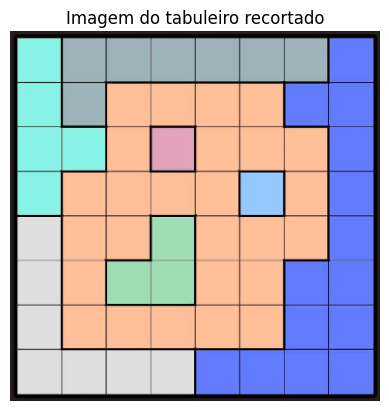

In [6]:
# função que gera a matriz de cores do tabuleiro a partir da imagem do tabuleiro
def gerar_matriz_tabuleiro(tabuleiro_recortado):
  # redimensiona o tabuleiro para um tamanho fixo padrão para facilitar os cálculos
  tabuleiro_padrao = cv2.resize(tabuleiro_recortado, (400, 400))
  # calcula o tamanho aproximado de cada célula (quadradinho no tabuleiro)
  tamanho_celula = 400 // 8
  # inicia lista que amazenará as cores de cada célula
  cores_tabuleiro = []
  # percorre todo o tabuleiro (linhas x colunas)
  for linha in range(TAMANHO_CONJUNTO):
    for coluna in range(TAMANHO_CONJUNTO):
      # calcula o pixel central exato de cada quadradinho para evitar pegar as linhas pretas da borda
      centro_y = (linha * tamanho_celula) + (tamanho_celula // 2)
      centro_x = (coluna * tamanho_celula) + (tamanho_celula // 2)
      # coleta a cor daquele ponto/célula no tabuleiro
      cor_pixel = tabuleiro_padrao[centro_y, centro_x]
      # guarda a cor na lista de cores das células (quadradinho)
      cores_tabuleiro.append(cor_pixel)
  # aplica algoritmo de clusterização sobre a lista de cores das células/quadradinhos
  # K = 8 (clusters) e semente fixa (42)
  kmeans = KMeans(n_clusters=8, random_state=SEED)
  # armezena predição de clusters da lista de cores do tabuleiro
  labels_cores = kmeans.fit_predict(cores_tabuleiro)
  # transformar a lista de 64 resultados em uma matriz 8x8
  tabuleiro_matriz_cores = labels_cores.reshape(8, 8)
  # exibe mapeamento da matriz do tabuleiro
  # print("\nMapeamento dos quadradinhos (matriz):")
  # print(tabuleiro_matriz_cores)
  # print("\n")
  # exibe tabuleiro recortado para comparação com matriz
  plt.imshow(tabuleiro_padrao, cmap='gray')
  plt.title("Imagem do tabuleiro recortado")
  plt.axis('off')
  plt.show()
  # retorna matriz mapeada do tabuleiro
  return tabuleiro_matriz_cores

matriz_tabuleiro = gerar_matriz_tabuleiro(tabuleiro_recortado)

# **Cálculo de Conflitos**

In [7]:
# função que calcula conflitos de rainhas no tabuleiro
def calcular_conflitos(estado, tabuleiro_cores):
  # inicia com 0 conflitos
  conflitos = 0
  # percorre as as posições no tabuleiro
  for i in range(TAMANHO_CONJUNTO):
    for j in range(i + 1, TAMANHO_CONJUNTO):
      # verifica se há rainhas em diagonais adjacentes
      if abs(i - j) == 1 and abs(estado[i] - estado[j]) == 1:
        conflitos += 1
      # guarda a cor (grupo) que pertencem duas rainhas
      cor_rainha1 = tabuleiro_cores[i][estado[i]]
      cor_rainha2 = tabuleiro_cores[j][estado[j]]
      # verifica se essas duas rainhas estão na mesma cor (grupo)
      if cor_rainha1 == cor_rainha2:
        conflitos += 1
      # verifica se há rainhas na mesma linha
      if estado[i] == estado[j]:
        conflitos += 1
  # exibe a quantidade de conflitos no tabuleiro
  # print(f"Quantidade de conflitos: {conflitos}\n")
  # retorna a quantidade de conflitos
  return conflitos

# representação dos estados
    # linhas: indice do vetor
    # colunas: valor em cada indice 

# estado aleatório para teste
estado = [1, 3, 4, 7, 0, 2, 5, 6]
conflitos = calcular_conflitos(estado, matriz_tabuleiro)

## **Heurística**

In [8]:
# regras
def posicaoValida(estadoAtual, novaColuna, matriz_tabuleiro):
    novaLinha = len(estadoAtual)
    novaCor = matriz_tabuleiro[novaLinha][novaColuna]

    for linhaExistente, colunaExistente in enumerate(estadoAtual):
        # restrição de coluna
        if colunaExistente == novaColuna:
            return False
        # restrição de cor
        corExistente = matriz_tabuleiro[linhaExistente][colunaExistente]
        if corExistente == novaCor:
            return False
        
        # restrição de vizinhos diretos
        if abs(linhaExistente - novaLinha) <= 1 and abs(colunaExistente - novaColuna) <= 1:
            return False
    return True

# função para gerar as próximas jogadas
def gerarProximasJogadas(tabuleiro_atual, matriz_tabuleiro):
    # inicializa uma lista vazia para armazenar as próximas jogadas válidas (estados filhos)
    novasJogadas = []
    # se o tabuleiro (pai) já possui 8 rainhas, finalia o jogo
    if len(tabuleiro_atual) >= 8:
        return novasJogadas
    # percorre cada uma das 8 colunas possíveis
    for coluna in range(8):
        # verifica se colocar uma rainha nessa coluna descumpre alguma regra
        if posicaoValida(tabuleiro_atual, coluna, matriz_tabuleiro):
            # se for uma posição segura, cria a nova configuração a partir da nova coluna
            novasJogadas.append(tabuleiro_atual + [coluna])

    # retorna o conjunto de todos as próximas jogadas válidas encontradas
    return novasJogadas

def heuristica(estado, tabuleiro):
    cores_utilizadas = set()

    # percorre estado
    for i in range(len(estado)):
        # salva todas as cores que já foram preenchidas com uma rainha
        cores_utilizadas.add(tabuleiro[i][estado[i]])
    
    # verifica a quantidade de cores que faltam para serem preenchidas
    cores_que_faltam = 8 - len(cores_utilizadas)
    
    cores_disponiveis = set()
    
    # percorre o tabuleiro a partir da primeira linha que ainda não foi preenchida
    for i in range(len(estado), len(tabuleiro)):
        # percorre cada coluna
        for j in range(len(tabuleiro)):
            # verifica se a posições ainda é válida (não causa conflito de adjacência, coluna e cor)
            if posicaoValida(estado, j, tabuleiro):
                cor_encontrada = tabuleiro[i][j]
                # se a cor não tiver sido utilizada ainda
                if cor_encontrada not in cores_utilizadas:
                    # salva em cores disponiveis
                    cores_disponiveis.add(cor_encontrada)
    
    # se tiver diferença entre as cores que precisam ser preenchidas e as disponíveis no tabuleiro, retorna essa diferença. Senão, retorna zero
    return max(0, cores_que_faltam - len(cores_disponiveis))

# **BFS**

In [ ]:
# Algoritmo de Busca em Largura
def bfs(matriz_tabuleiro):
    historico_iteracoes = []

    # inicia o jogo
    estadoInicial = []
    # inicializa a fila de busca
    abertos = collections.deque([estadoInicial])
    # cria um conjunto de tabuleiros já testados
    fechados = set()
    # cria o dicionário para mapear o histórico de jogadas
    caminho = {str(estadoInicial): None}
    # inicializa o contador de iterações
    iteracoes = 0

    # enquanto existirem tabuleiros na fila para testar
    while len(abertos) > 0:
        # retira o tabuleiro mais antigo da fila.
        estadoAtual = abertos.popleft()

        # salva estado atual no histórico do algoritmo
        historico_iteracoes.append(heuristica(estadoAtual, matriz_tabuleiro))

        # se o tabuleiro atual tem 8 rainhas a solução foi encontrada
        if len(estadoAtual) == 8:
            return caminho, estadoAtual, iteracoes, historico_iteracoes
        # não visita os tabuleiros repetidos
        if tuple(estadoAtual) not in fechados:
            # adiciona o tabuleiro atual aos estados já visitados
            fechados.add(tuple(estadoAtual))
            # gera as próximas jogadas válidas (filhos do estado atual)
            novasJogadas = gerarProximasJogadas(estadoAtual, matriz_tabuleiro)
            # analisa cada filho gerado (nova jogada)
            for jogada in novasJogadas:
                # se é uma jogada nova e não está na fila
                if tuple(jogada) not in fechados and jogada not in abertos:
                    # Coloca a jogada no fim da fila
                    abertos.append(jogada)
                    # salva o caminho que este tabuleiro gerou essa jogada
                    caminho[str(jogada)] = str(estadoAtual)

        # incrementa as iterações
        iteracoes += 1

    # se não houver solução
    return "FALHA", None, iteracoes, historico_iteracoes

# **DFS**

In [ ]:
# Algoritmo de Busca em Profundidade
def dfs(matriz_tabuleiro, n_max=8):
    historico_iteracoes = []

    # reconstroi o caminho
    def reconstruir_caminho(caminho, estadoAtual):
        # lista para a sequência de jogadas
        rota = []
        # começa pelo estado final
        atual = estadoAtual
        # volta o histórico até o início
        while atual is not None:
            # guarda o tabuleiro atual na rota
            rota.append(atual)
            # converte em texto para buscar a chave
            atual_str = str(atual)
            # se o tabuleiro está no histórico
            if atual_str in caminho:
                # puxa o tabuleiro PAI anterior
                atual = caminho[atual_str]
            else:
                # para o loop
                atual = None
        # retorna o caminho completo
        return rota

    # inicia o jogo
    estadoInicial = []
    # inicializa a pilha de busca
    abertos = [estadoInicial]
    # cria um conjunto de tabuleiros já testados
    fechados = set()
    # cria o dicionário para mapear o histórico de jogadas
    caminho = {str(estadoInicial): None}
    # inicializa o contador de iterações
    iteracoes = 0

    # enquanto existirem tabuleiros na pilha para testar
    while len(abertos) > 0:
        # retira o tabuleiro do topo da pilha (último inserido = DFS)
        estadoAtual = abertos.pop()

        # salva estado atual no histórico do algoritmo
        historico_iteracoes.append(heuristica(estadoAtual, matriz_tabuleiro))
        
        # se o tabuleiro atual tem 8 rainhas a solução foi encontrada
        if len(estadoAtual) == 8:
            return caminho, estadoAtual, iteracoes, historico_iteracoes
        # converte para tupla para poder verificar no conjunto de fechados
        estadoTupla = tuple(estadoAtual)
        # não visita os tabuleiros repetidos
        if estadoTupla in fechados:
            continue

        # marca o tabuleiro atual como visitado
        fechados.add(estadoTupla)
        # atualiza quantidade de estados percorridos
        iteracoes += 1

        # gera os movimentos respeitando o limite máximo de profundidade (linhas)
        if len(estadoAtual) < n_max:
            # reconstroi o caminho até o estado atual para saber a profundidade real
            rota = reconstruir_caminho(caminho, estadoAtual)
            # chama a função de geração de novas jogadas
            filhos = gerarProximasJogadas(estadoAtual, matriz_tabuleiro)
            for filho in filhos:
                # se o estado filho não estiver na lista de fechados
                if tuple(filho) not in fechados:
                    # adiciona ao topo da pilha de estados abertos
                    abertos.append(filho)
                    # salva o estado pai (tabuleiro) dele no histórico de caminhos
                    caminho[str(filho)] = estadoAtual

    # se não houver solução
    return "FALHA", None, iteracoes, historico_iteracoes

# **Busca pela Melhor Escolha**

In [ ]:
# Algoritmo Busca pela Melhor Escolha
def buscaMelhorEscolha(tabuleiro):
    historico_iteracoes = []

    estadoInicial = []
    # inicializa listas de controle
    abertos = [(estadoInicial, 12, 0)] 
    fechados = []
    
    # inicializa dicionário com o estado inicial para guardar o caminho percorrido até atingir o objetivo
    caminho = {str(estadoInicial): None}

    # salva a quantidade de estados percorridos até atingir o objetivo
    iteracoes = 0

    #enquanto houver estados
    while len(abertos) > 0:
        # remove o estado mais à esquerda de abertos (segundo método heurístico)
        estadoAtual = abertos.pop(0)
        
        # salva estado atual no histórico do algoritmo
        historico_iteracoes.append(estadoAtual[1])

        # verifica se chegou a posição final
        if len(estadoAtual[0]) == 8:
            return caminho, estadoAtual[0], iteracoes, historico_iteracoes

        if len(estadoAtual[0]) < 8:
            # gera os próximos estados
            filhos = gerarProximasJogadas(estadoAtual[0], tabuleiro)
            # gerarFilhos(estadoAtual[0], caminho, estadoInicial)
            
            # percorre cada filho gerado
            for filho in filhos:
                # atribui a referência do estado pai para cada filho gerado
                caminho[str(filho)] = str(estadoAtual[0])

                # inicializa tupla
                tupla = None
                
                # se o estado filho não estiver na lista de fechados ou abertos
                if filho not in [f[0] for f in fechados] or filho not in [a[0] for a in abertos]:
                    # cria tupla do filho atual, calcula a função f dele e salva a informação do nível atual
                    tupla = (filho, heuristica(filho, tabuleiro), estadoAtual[2] + 1)
                    # adiciona filho à lista de abertos (estados não explorados)
                    abertos.append(tupla)
        
                # percorre lista de estados abertos
                for i, a in enumerate(abertos):
                    # se o filho atual já estiver na lista de estados e o filho atual tiver um nível menor do que o encontrado na lista de abertos
                    if a[0] == filho and a[2] > (estadoAtual[2] + 1):
                        # remove estado encontrado da lista de abertos
                        abertos.pop(i)
                        # adiciona o filho atual à lista de abertos
                        abertos.append((filho, heuristica(filho, tabuleiro), estadoAtual[2] + 1))
                        # atualiza caminho do estado encontrado (caminho mais curto)
                        caminho[str(a[0])] = caminho[str(filho)]
                        break
                for i, a in enumerate(fechados):
                    if a[0] == filho and a[2] > (estadoAtual[2] + 1):
                        # remove o estado encontrado da lista de fechados
                        fechados.pop(i)
                        # adiciona o filho atual à lista de abertos
                        abertos.append((filho, heuristica(filho, tabuleiro), estadoAtual[2] + 1))
                        break
        
        fechados.append(estadoAtual)
        
        # ordena a lista de abertos de forma crescente sengundo a função f() 
        abertos.sort(key=lambda x: x[1])

        # incrementa o número de iterações
        iteracoes += 1
        
    return caminho, "FALHA", iteracoes, historico_iteracoes

# **A\***

In [ ]:
# Algoritmo A*
def aEstrela(tabuleiro):
    historico_iteracoes = []

    def f(estadoCorrente, g, tabuleiro):
        # inverte a lógica de níveis: quanto mais próximo da solução, menor o nível
        qtd_niveis = 8 - g
        # calcula a soma entre a heurística adotada e a quantidade de níveis do estado corrente até o estado inicial
        return heuristica(estadoCorrente, tabuleiro) + qtd_niveis

    estadoInicial = []
    # inicializa listas de controle
    abertos = [(estadoInicial, 12, 0)] 
    fechados = []
    
    # inicializa dicionário com o estado inicial para guardar o caminho percorrido até atingir o objetivo
    caminho = {str(estadoInicial): None}

    # salva a quantidade de estados percorridos até atingir o objetivo
    iteracoes = 0

    #enquanto houver estados
    while len(abertos) > 0:
        # remove o estado mais à esquerda de abertos (segundo método heurístico)
        estadoAtual = abertos.pop(0)

        # salva estado atual no histórico do algoritmo
        historico_iteracoes.append(heuristica(estadoAtual[0], tabuleiro))
        # verifica se atingiu o estado ótimo
        if estadoAtual[1] == 0:
            return caminho, estadoAtual[0], iteracoes, historico_iteracoes

        if len(estadoAtual[0]) < 8:
            # gera os próximos estados
            filhos = gerarProximasJogadas(estadoAtual[0], tabuleiro)
            # gerarFilhos(estadoAtual[0], caminho, estadoInicial)
            
            # percorre cada filho gerado
            for filho in filhos:
                # atribui a referência do estado pai para cada filho gerado
                caminho[str(filho)] = str(estadoAtual[0])

                # inicializa tupla
                tupla = None
                
                # se o estado filho não estiver na lista de fechados ou abertos
                if filho not in [f[0] for f in fechados] or filho not in [a[0] for a in abertos]:
                    # cria tupla do filho atual, calcula a função f dele e salva a informação do nível atual
                    tupla = (filho, f(filho, estadoAtual[2] + 1, tabuleiro), estadoAtual[2] + 1)
                    # adiciona filho à lista de abertos (estados não explorados)
                    abertos.append(tupla)
        
                # percorre lista de estados abertos
                for i, a in enumerate(abertos):
                    # se o filho atual já estiver na lista de estados e o filho atual tiver um nível menor do que o encontrado na lista de abertos
                    if a[0] == filho and a[2] > (estadoAtual[2] + 1):
                        # remove estado encontrado da lista de abertos
                        abertos.pop(i)
                        # adiciona o filho atual à lista de abertos
                        abertos.append((filho, f(filho, estadoAtual[2] + 1, tabuleiro), estadoAtual[2] + 1))
                        # atualiza caminho do estado encontrado (caminho mais curto)
                        caminho[str(a[0])] = caminho[str(filho)]
                        break
                for i, a in enumerate(fechados):
                    if a[0] == filho and a[2] > (estadoAtual[2] + 1):
                        # remove o estado encontrado da lista de fechados
                        fechados.pop(i)
                        # adiciona o filho atual à lista de abertos
                        abertos.append((filho, f(filho, estadoAtual[2] + 1, tabuleiro), estadoAtual[2] + 1))
                        break
        
        fechados.append(estadoAtual)
        
        # ordena a lista de abertos de forma crescente sengundo a função f() 
        abertos.sort(key=lambda x: x[1])

        # incrementa o número de iterações
        iteracoes += 1
        
    return caminho, "FALHA", iteracoes, historico_iteracoes


# **Simulated Annealing**

In [ ]:
# Algoritmo Simulated Annealing
def recozimento_simulado(matriz_tabuleiro):
    # redefine as seeds para aleatorizar sempre a partir do mesmo ponto de partida
    random.seed(SEED)
    np.random.seed(SEED)

    # redefine a função de custo com a nova configuração do tabuleiro
    def f_cost(solution): return calcular_conflitos(solution, matriz_tabuleiro)
    
    # instancia um objeto do algoritmo da biblioteca SKO
        # função a ser minimizada: função de custo, ou seja, quantidade de conflitos identificados
        # x0: estado inicial [0, 1, 2, 3, 4, 5, 6, 7]
        # L (long of chain): quantidade de tentativas em um mesma iteração
        # max_stay_counter: quantidade de iterações máxima depois de estabilizar em um estado
    sa = SA_TSP(func=f_cost, x0=list(range(8)), L=250, max_stay_counter=1000)

    # executa algoritmo e obtém o estado final e a quantidade de conflitos na solução final
    melhor_solucao, melhor_custo = sa.run()
    # calcula a quantidade de iterações a partir do tamanho de melhores estados gerados por iteração
    qtd_iteracoes = (list(sa.best_y_history)).index(melhor_custo) + 1
    
    # se o melhor custo obtido não for zero
    if melhor_custo != 0:
        # o algoritmo falhou para encontrar uma solução
        melhor_solucao = "FALHA"
    else:
        # senão, ele encontrou
        melhor_solucao = [int(i) for i in melhor_solucao]
    
    return melhor_solucao, qtd_iteracoes, sa.best_y_history

# **Algoritmo Genético**

In [ ]:
# Algoritmo Genético (AG)
def algoritmo_genetico(matriz_tabuleiro):
    # redefine as seeds para aleatorizar sempre a partir do mesmo ponto de partida
    random.seed(SEED)
    np.random.seed(SEED)
    
    # redefine a função de custo com a nova configuração do tabuleiro
    def f_cost(solution): return calcular_conflitos(solution, matriz_tabuleiro)

    # instancia um objeto do algoritmo da biblioteca SKO
        # função a ser minimizada: função de custo, ou seja, quantidade de conflitos identificados
        # ndim: dimensão do problema
        # size_pop: quantidade de indíviduos por população
        # prob_mut: probabilidade de mutação
        # max_iter: quantidade máxima de iterações
    ga = GA_TSP(func=f_cost, n_dim=8, size_pop=250, prob_mut=0.20, max_iter=1000)
    # executa algoritmo e obtém o estado final e a quantidade de conflitos na solução final
    melhor_solucao, melhor_custo = ga.run()
    # calcula a quantidade de iterações a partir do tamanho de melhores estados gerados por iteração
    qtd_iteracoes = (list(ga.generation_best_Y)).index(melhor_custo) + 1
    
    # se o melhor custo obtido não for zero
    if melhor_custo != 0:
        # o algoritmo falhou para encontrar uma solução
        melhor_solucao = "FALHA"
    else:
        # senão, ele encontrou
        melhor_solucao = [int(i) for i in melhor_solucao]
    
    return melhor_solucao, qtd_iteracoes, ga.generation_best_Y 

# **Pipeline**

In [16]:
# Função que exibe o resultado final obtido por cada algoritmo
def exibe_resultado(estadoFinal, qtdIteracoes, algoritmo):
    # se o algoritmo falhou em encontrar uma solução
    if estadoFinal == "FALHA" or estadoFinal is None:
        # exibe mensagem de erro
        print("Não foi possível encontrar uma solução para este tabuleiro")
    # senão
    else:
        # exibe a quantidade de iterações necessárias para alcançar a solução e o estado final obtido
        print(f"Jogo resolvido em {qtdIteracoes} iterações pelo {algoritmo}!")
        print(f"Posicionamento das rainhas: {estadoFinal}")

        # exibe a configuração final do tabuleiro no formato de uma matriz 8x8, onde o número 0 indica posições vazias e o número 1 corresponde às posições das rainhas
        print("\nMatriz Final:")
        # inicializa tabuleiro vazio
        tabuleiro_visual = [[0]*8 for _ in range(8)]
        for linha, col in enumerate(estadoFinal):
            # preenche a posição das rainhas igual ao encontrado na solução final
            tabuleiro_visual[linha][col] = 1
        
        # exibe tabuleiro
        for linha in tabuleiro_visual:
            print(linha)


########################################################################
####################### MAPEAMENTO TABULEIRO 001 #######################
########################################################################



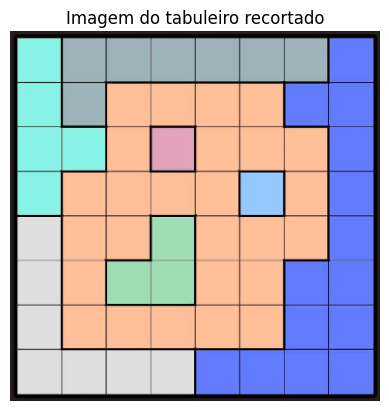



########################################################################
Busca em largura (BFS)
Jogo resolvido em 867 iterações pelo BFS!
Posicionamento das rainhas: [6, 0, 3, 5, 7, 2, 4, 1]

Matriz Final:
[0, 0, 0, 0, 0, 0, 1, 0]
[1, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 1, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 1, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 1]
[0, 0, 1, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 1, 0, 0, 0]
[0, 1, 0, 0, 0, 0, 0, 0]


########################################################################
Busca em profundidade (DFS)
Jogo resolvido em 189 iterações pelo DFS!
Posicionamento das rainhas: [6, 0, 3, 5, 7, 2, 4, 1]

Matriz Final:
[0, 0, 0, 0, 0, 0, 1, 0]
[1, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 1, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 1, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 1]
[0, 0, 1, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 1, 0, 0, 0]
[0, 1, 0, 0, 0, 0, 0, 0]


########################################################################
Busca Melhor Escolha (Gulosa)
Jogo resolvido em 30 iterações pelo Busca Melhor Escolha!
Posicionamento d

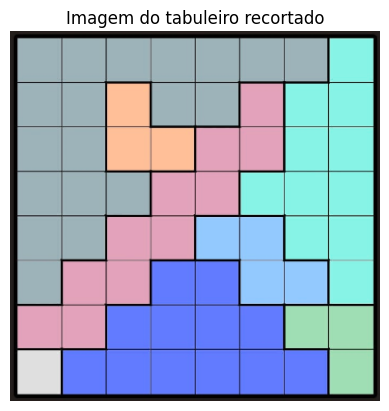



########################################################################
Busca em largura (BFS)
Jogo resolvido em 190 iterações pelo BFS!
Posicionamento das rainhas: [7, 2, 4, 1, 5, 3, 6, 0]

Matriz Final:
[0, 0, 0, 0, 0, 0, 0, 1]
[0, 0, 1, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 1, 0, 0, 0]
[0, 1, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 1, 0, 0]
[0, 0, 0, 1, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 1, 0]
[1, 0, 0, 0, 0, 0, 0, 0]


########################################################################
Busca em profundidade (DFS)
Jogo resolvido em 28 iterações pelo DFS!
Posicionamento das rainhas: [7, 2, 4, 1, 5, 3, 6, 0]

Matriz Final:
[0, 0, 0, 0, 0, 0, 0, 1]
[0, 0, 1, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 1, 0, 0, 0]
[0, 1, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 1, 0, 0]
[0, 0, 0, 1, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 1, 0]
[1, 0, 0, 0, 0, 0, 0, 0]


########################################################################
Busca Melhor Escolha (Gulosa)
Jogo resolvido em 84 iterações pelo Busca Melhor Escolha!
Posicionamento da

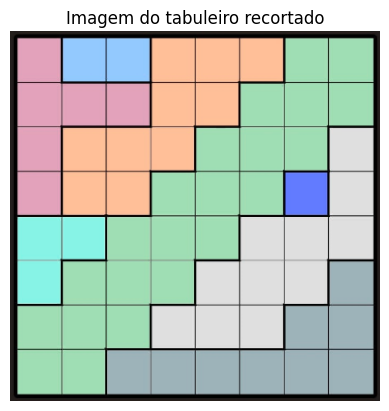



########################################################################
Busca em largura (BFS)
Jogo resolvido em 641 iterações pelo BFS!
Posicionamento das rainhas: [2, 4, 0, 6, 1, 3, 5, 7]

Matriz Final:
[0, 0, 1, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 1, 0, 0, 0]
[1, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 1, 0]
[0, 1, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 1, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 1, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 1]


########################################################################
Busca em profundidade (DFS)
Jogo resolvido em 338 iterações pelo DFS!
Posicionamento das rainhas: [2, 4, 0, 6, 1, 3, 5, 7]

Matriz Final:
[0, 0, 1, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 1, 0, 0, 0]
[1, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 1, 0]
[0, 1, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 1, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 1, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 1]


########################################################################
Busca Melhor Escolha (Gulosa)
Jogo resolvido em 17 iterações pelo Busca Melhor Escolha!
Posicionamento d

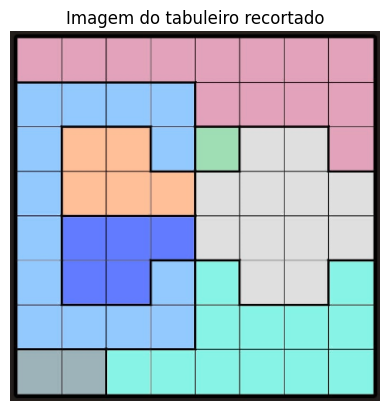



########################################################################
Busca em largura (BFS)
Jogo resolvido em 542 iterações pelo BFS!
Posicionamento das rainhas: [6, 2, 4, 1, 3, 5, 7, 0]

Matriz Final:
[0, 0, 0, 0, 0, 0, 1, 0]
[0, 0, 1, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 1, 0, 0, 0]
[0, 1, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 1, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 1, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 1]
[1, 0, 0, 0, 0, 0, 0, 0]


########################################################################
Busca em profundidade (DFS)
Jogo resolvido em 140 iterações pelo DFS!
Posicionamento das rainhas: [6, 2, 4, 1, 3, 5, 7, 0]

Matriz Final:
[0, 0, 0, 0, 0, 0, 1, 0]
[0, 0, 1, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 1, 0, 0, 0]
[0, 1, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 1, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 1, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 1]
[1, 0, 0, 0, 0, 0, 0, 0]


########################################################################
Busca Melhor Escolha (Gulosa)
Jogo resolvido em 239 iterações pelo Busca Melhor Escolha!
Posicionamento 

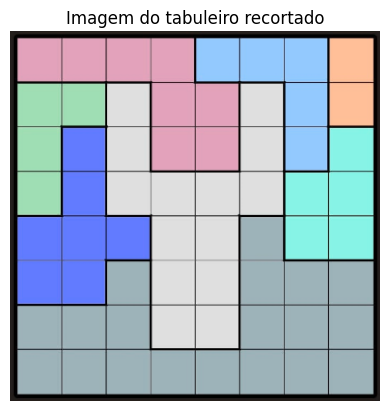



########################################################################
Busca em largura (BFS)
Jogo resolvido em 2236 iterações pelo BFS!
Posicionamento das rainhas: [5, 7, 3, 0, 6, 1, 4, 2]

Matriz Final:
[0, 0, 0, 0, 0, 1, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 1]
[0, 0, 0, 1, 0, 0, 0, 0]
[1, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 1, 0]
[0, 1, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 1, 0, 0, 0]
[0, 0, 1, 0, 0, 0, 0, 0]


########################################################################
Busca em profundidade (DFS)
Jogo resolvido em 920 iterações pelo DFS!
Posicionamento das rainhas: [5, 7, 3, 0, 6, 1, 4, 2]

Matriz Final:
[0, 0, 0, 0, 0, 1, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 1]
[0, 0, 0, 1, 0, 0, 0, 0]
[1, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 1, 0]
[0, 1, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 1, 0, 0, 0]
[0, 0, 1, 0, 0, 0, 0, 0]


########################################################################
Busca Melhor Escolha (Gulosa)
Jogo resolvido em 26 iterações pelo Busca Melhor Escolha!
Posicionamento 

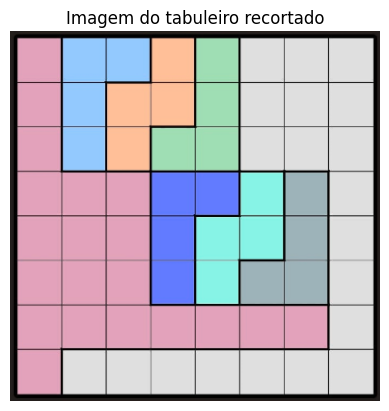



########################################################################
Busca em largura (BFS)
Jogo resolvido em 1653 iterações pelo BFS!
Posicionamento das rainhas: [1, 4, 2, 5, 3, 6, 0, 7]

Matriz Final:
[0, 1, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 1, 0, 0, 0]
[0, 0, 1, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 1, 0, 0]
[0, 0, 0, 1, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 1, 0]
[1, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 1]


########################################################################
Busca em profundidade (DFS)
Jogo resolvido em 1378 iterações pelo DFS!
Posicionamento das rainhas: [1, 4, 2, 5, 3, 6, 0, 7]

Matriz Final:
[0, 1, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 1, 0, 0, 0]
[0, 0, 1, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 1, 0, 0]
[0, 0, 0, 1, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 1, 0]
[1, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 1]


########################################################################
Busca Melhor Escolha (Gulosa)
Jogo resolvido em 58 iterações pelo Busca Melhor Escolha!
Posicionamento

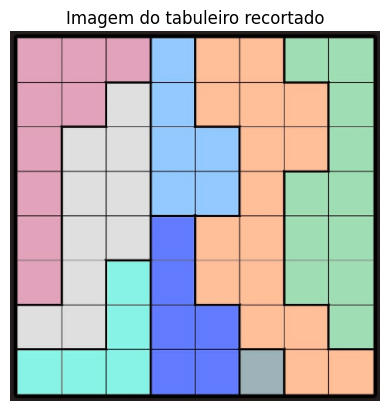



########################################################################
Busca em largura (BFS)
Jogo resolvido em 1050 iterações pelo BFS!
Posicionamento das rainhas: [0, 6, 4, 1, 3, 7, 2, 5]

Matriz Final:
[1, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 1, 0]
[0, 0, 0, 0, 1, 0, 0, 0]
[0, 1, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 1, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 1]
[0, 0, 1, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 1, 0, 0]


########################################################################
Busca em profundidade (DFS)
Jogo resolvido em 872 iterações pelo DFS!
Posicionamento das rainhas: [0, 6, 4, 1, 3, 7, 2, 5]

Matriz Final:
[1, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 1, 0]
[0, 0, 0, 0, 1, 0, 0, 0]
[0, 1, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 1, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 1]
[0, 0, 1, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 1, 0, 0]


########################################################################
Busca Melhor Escolha (Gulosa)
Jogo resolvido em 309 iterações pelo Busca Melhor Escolha!
Posicionamento

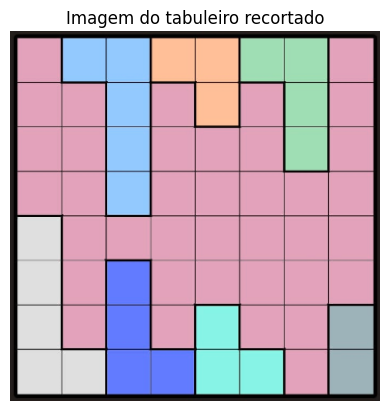



########################################################################
Busca em largura (BFS)
Jogo resolvido em 148 iterações pelo BFS!
Posicionamento das rainhas: [1, 4, 6, 3, 0, 2, 7, 5]

Matriz Final:
[0, 1, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 1, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 1, 0]
[0, 0, 0, 1, 0, 0, 0, 0]
[1, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 1, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 1]
[0, 0, 0, 0, 0, 1, 0, 0]


########################################################################
Busca em profundidade (DFS)
Jogo resolvido em 135 iterações pelo DFS!
Posicionamento das rainhas: [1, 4, 6, 3, 0, 2, 7, 5]

Matriz Final:
[0, 1, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 1, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 1, 0]
[0, 0, 0, 1, 0, 0, 0, 0]
[1, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 1, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 1]
[0, 0, 0, 0, 0, 1, 0, 0]


########################################################################
Busca Melhor Escolha (Gulosa)
Jogo resolvido em 45 iterações pelo Busca Melhor Escolha!
Posicionamento d

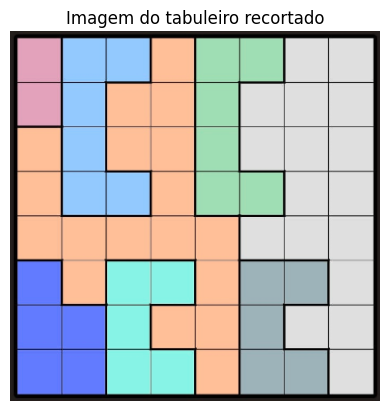



########################################################################
Busca em largura (BFS)
Jogo resolvido em 561 iterações pelo BFS!
Posicionamento das rainhas: [5, 0, 7, 2, 4, 6, 1, 3]

Matriz Final:
[0, 0, 0, 0, 0, 1, 0, 0]
[1, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 1]
[0, 0, 1, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 1, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 1, 0]
[0, 1, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 1, 0, 0, 0, 0]


########################################################################
Busca em profundidade (DFS)
Jogo resolvido em 108 iterações pelo DFS!
Posicionamento das rainhas: [5, 0, 7, 2, 4, 6, 1, 3]

Matriz Final:
[0, 0, 0, 0, 0, 1, 0, 0]
[1, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 1]
[0, 0, 1, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 1, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 1, 0]
[0, 1, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 1, 0, 0, 0, 0]


########################################################################
Busca Melhor Escolha (Gulosa)
Jogo resolvido em 286 iterações pelo Busca Melhor Escolha!
Posicionamento 

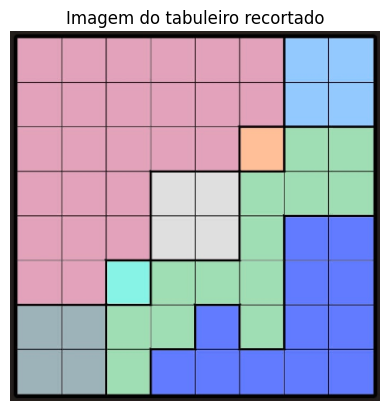



########################################################################
Busca em largura (BFS)
Jogo resolvido em 138 iterações pelo BFS!
Posicionamento das rainhas: [6, 1, 5, 7, 4, 2, 0, 3]

Matriz Final:
[0, 0, 0, 0, 0, 0, 1, 0]
[0, 1, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 1, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 1]
[0, 0, 0, 0, 1, 0, 0, 0]
[0, 0, 1, 0, 0, 0, 0, 0]
[1, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 1, 0, 0, 0, 0]


########################################################################
Busca em profundidade (DFS)
Jogo resolvido em 75 iterações pelo DFS!
Posicionamento das rainhas: [6, 1, 5, 7, 4, 2, 0, 3]

Matriz Final:
[0, 0, 0, 0, 0, 0, 1, 0]
[0, 1, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 1, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 1]
[0, 0, 0, 0, 1, 0, 0, 0]
[0, 0, 1, 0, 0, 0, 0, 0]
[1, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 1, 0, 0, 0, 0]


########################################################################
Busca Melhor Escolha (Gulosa)
Jogo resolvido em 21 iterações pelo Busca Melhor Escolha!
Posicionamento da

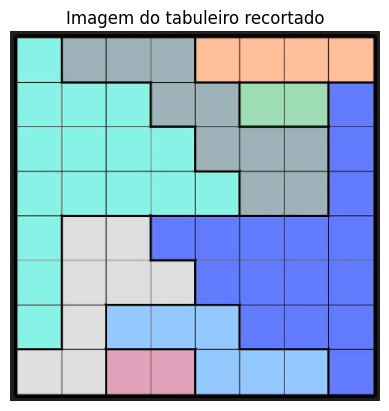



########################################################################
Busca em largura (BFS)
Jogo resolvido em 419 iterações pelo BFS!
Posicionamento das rainhas: [7, 5, 0, 6, 3, 1, 4, 2]

Matriz Final:
[0, 0, 0, 0, 0, 0, 0, 1]
[0, 0, 0, 0, 0, 1, 0, 0]
[1, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 1, 0]
[0, 0, 0, 1, 0, 0, 0, 0]
[0, 1, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 1, 0, 0, 0]
[0, 0, 1, 0, 0, 0, 0, 0]


########################################################################
Busca em profundidade (DFS)
Jogo resolvido em 39 iterações pelo DFS!
Posicionamento das rainhas: [7, 5, 0, 6, 3, 1, 4, 2]

Matriz Final:
[0, 0, 0, 0, 0, 0, 0, 1]
[0, 0, 0, 0, 0, 1, 0, 0]
[1, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 1, 0]
[0, 0, 0, 1, 0, 0, 0, 0]
[0, 1, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 1, 0, 0, 0]
[0, 0, 1, 0, 0, 0, 0, 0]


########################################################################
Busca Melhor Escolha (Gulosa)
Jogo resolvido em 101 iterações pelo Busca Melhor Escolha!
Posicionamento d

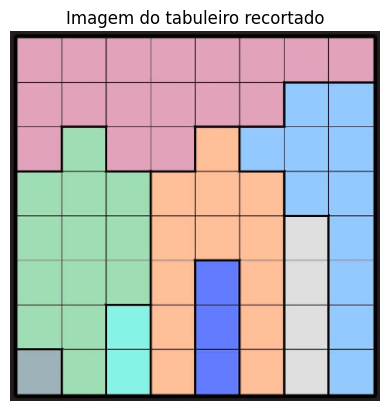



########################################################################
Busca em largura (BFS)
Jogo resolvido em 106 iterações pelo BFS!
Posicionamento das rainhas: [5, 7, 1, 3, 6, 4, 2, 0]

Matriz Final:
[0, 0, 0, 0, 0, 1, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 1]
[0, 1, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 1, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 1, 0]
[0, 0, 0, 0, 1, 0, 0, 0]
[0, 0, 1, 0, 0, 0, 0, 0]
[1, 0, 0, 0, 0, 0, 0, 0]


########################################################################
Busca em profundidade (DFS)
Jogo resolvido em 19 iterações pelo DFS!
Posicionamento das rainhas: [5, 7, 1, 3, 6, 4, 2, 0]

Matriz Final:
[0, 0, 0, 0, 0, 1, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 1]
[0, 1, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 1, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 1, 0]
[0, 0, 0, 0, 1, 0, 0, 0]
[0, 0, 1, 0, 0, 0, 0, 0]
[1, 0, 0, 0, 0, 0, 0, 0]


########################################################################
Busca Melhor Escolha (Gulosa)
Jogo resolvido em 99 iterações pelo Busca Melhor Escolha!
Posicionamento da

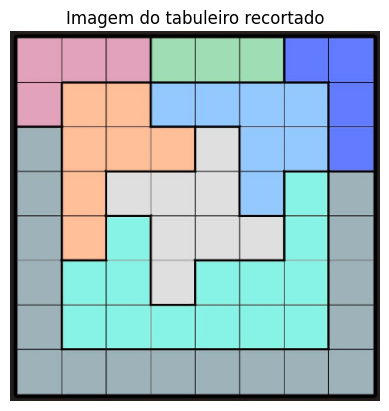



########################################################################
Busca em largura (BFS)
Jogo resolvido em 2730 iterações pelo BFS!
Posicionamento das rainhas: [4, 0, 7, 5, 1, 3, 6, 2]

Matriz Final:
[0, 0, 0, 0, 1, 0, 0, 0]
[1, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 1]
[0, 0, 0, 0, 0, 1, 0, 0]
[0, 1, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 1, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 1, 0]
[0, 0, 1, 0, 0, 0, 0, 0]


########################################################################
Busca em profundidade (DFS)
Jogo resolvido em 1218 iterações pelo DFS!
Posicionamento das rainhas: [4, 0, 7, 5, 1, 3, 6, 2]

Matriz Final:
[0, 0, 0, 0, 1, 0, 0, 0]
[1, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 1]
[0, 0, 0, 0, 0, 1, 0, 0]
[0, 1, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 1, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 1, 0]
[0, 0, 1, 0, 0, 0, 0, 0]


########################################################################
Busca Melhor Escolha (Gulosa)
Jogo resolvido em 13 iterações pelo Busca Melhor Escolha!
Posicionamento

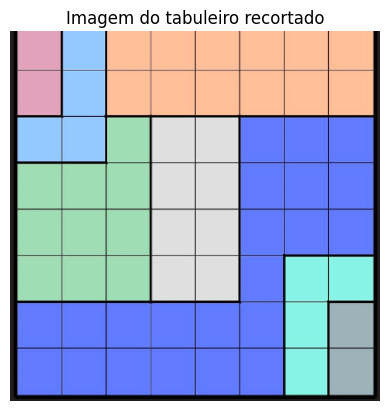



########################################################################
Busca em largura (BFS)
Jogo resolvido em 1251 iterações pelo BFS!
Posicionamento das rainhas: [0, 5, 1, 4, 2, 6, 3, 7]

Matriz Final:
[1, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 1, 0, 0]
[0, 1, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 1, 0, 0, 0]
[0, 0, 1, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 1, 0]
[0, 0, 0, 1, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 1]


########################################################################
Busca em profundidade (DFS)
Jogo resolvido em 1064 iterações pelo DFS!
Posicionamento das rainhas: [0, 5, 1, 4, 2, 6, 3, 7]

Matriz Final:
[1, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 1, 0, 0]
[0, 1, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 1, 0, 0, 0]
[0, 0, 1, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 1, 0]
[0, 0, 0, 1, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 1]


########################################################################
Busca Melhor Escolha (Gulosa)
Jogo resolvido em 24 iterações pelo Busca Melhor Escolha!
Posicionamento

In [ ]:
# históricos para armazenar as heurísticas/custos de cada estado avaliado em cada algoritmo
historico_algoritmos_deterministicos = {"BFS": [], "DFS": [], "Busca Melhor Escolha": [], "A*": []}
historico_algoritmos_nao_deterministicos = {"SA": [], "AG": []}

def pipeline():

  for id_imagem in range(1, QUANTIDADE_IMAGENS + 1):
    print("\n########################################################################")
    print(f"####################### MAPEAMENTO TABULEIRO {id_imagem:03d} #######################")
    print("########################################################################\n")
    # função que carrega as imagens (prints) do tabuleiro
    print_tabuleiro = carregar_imagens_tabuleiro(id_imagem)
    # função que recorta a região de interesse (tabuleiro) do print automaticamente
    tabuleiro_recortado = recortar_imagem_tabuleiro(print_tabuleiro)
    # função que gera a matriz de cores do tabuleiro a partir da imagem do tabuleiro
    matriz_tabuleiro = gerar_matriz_tabuleiro(tabuleiro_recortado)

    # Algoritmos determinísticos
    print("\n\n########################################################################")
    print("Busca em largura (BFS)")
    caminho, estadoFinal, qtdIteracoes, historico = bfs(matriz_tabuleiro)
    historico_algoritmos_deterministicos["BFS"].append(historico)
    exibe_resultado(estadoFinal, qtdIteracoes, "BFS")

    print("\n\n########################################################################")
    print("Busca em profundidade (DFS)")
    caminho, estadoFinal, qtdIteracoes, historico = dfs(matriz_tabuleiro)
    historico_algoritmos_deterministicos["DFS"].append(historico)
    exibe_resultado(estadoFinal, qtdIteracoes, "DFS")

    print("\n\n########################################################################")
    print("Busca Melhor Escolha (Gulosa)")
    caminho, estadoFinal, iteracoes, historico = buscaMelhorEscolha(matriz_tabuleiro)
    historico_algoritmos_deterministicos["Busca Melhor Escolha"].append(historico)
    exibe_resultado(estadoFinal, iteracoes, "Busca Melhor Escolha")

    print("\n\n########################################################################")
    print("A*")
    caminho, estadoFinal, iteracoes, historico = aEstrela(matriz_tabuleiro)
    historico_algoritmos_deterministicos["A*"].append(historico)
    exibe_resultado(estadoFinal, iteracoes, "A*")

    # Algoritmos não determinísticos
    print("\n\n########################################################################")
    print("Simulated Annealing (SA)\n")
    estadoFinal, qtdIteracoes, historico = recozimento_simulado(matriz_tabuleiro)
    historico_algoritmos_nao_deterministicos["SA"].append(historico)
    exibe_resultado(estadoFinal, qtdIteracoes, "SA")

    print("\n\n########################################################################")
    print("Algoritmo Genético (AG))\n")
    estadoFinal, qtdIteracoes, historico = algoritmo_genetico(matriz_tabuleiro)
    historico_algoritmos_nao_deterministicos["AG"].append(historico)
    exibe_resultado(estadoFinal, qtdIteracoes, "AG")

pipeline()

# **Análise de Resultados**

In [56]:
def exibe_graficos_convergência(historico_algoritmos, deterministico):
    # define fundo escuro para o gráfico
    plt.style.use('dark_background')

    # percorre cada um dos algoritmos
    for algoritmo in historico_algoritmos:
        # cria subplot com 7 linhas e 2 colunas
        fig, axs = plt.subplots(7, 2, figsize=(15, 20), sharey='row')

        # inicializa variáveis de controle
        linha, coluna = 0, 0
        contador = 0
        
        print("########################################################################")
        print(f'{algoritmo}\n')
        for i in range(14):
            # se o algoritmo é determinístico
            if deterministico:
                # pega o histórico inteiro do algoritmo
                buffer = historico_algoritmos[algoritmo][i]
            # senão
            else:
                # pega até a iteração em que ele encontrou a solução ótima (seleciona 10 posições a mais para plotar o gráfico de casos em que o algoritmo converge muito rápido)
                buffer = historico_algoritmos[algoritmo][i][0:historico_algoritmos[algoritmo][i].index(0) + 10]

            # define o eixo x, y, cor e estilo da linha do gráfico
            axs[linha, coluna].plot(range(len(buffer)), buffer, color='red', linestyle='--')
            axs[linha, coluna].set_title(f'Tabuleiro {i + 1}')
            
            # se estiver na última linha do subplot
            if linha == 6:
                # escreve a legenda do eixo x
                axs[linha, coluna].set_xlabel('Iterações')

            # se estiver na primeira coluna do subplot
            if coluna == 0:
                # escreve a legenda do eixo y de acordo com o tipo de função utilizada na avaliação
                if deterministico:
                    axs[linha, coluna].set_ylabel('Heurísticca')
                else:
                    axs[linha, coluna].set_ylabel('Função de custo')

            # atualiza variáveis de controle
            coluna += 1
            contador += 1

            # quando plotar dois gráficos
            if contador == 2:
                # troca a linha
                linha += 1
                # retorna a coluna para a posição inicial
                coluna = 0
                # reseta contador
                contador = 0

        # plota gráficos    
        plt.tight_layout()
        plt.show()


In [ ]:
def exibe_quantidade_iteracoes(historico_algoritmos, deterministico):
    # percorre cada um dos algoritmos
    for algoritmo in historico_algoritmos:
        print("########################################################################")
        print(f'{algoritmo}\n')

        # inicializa buffer que irá guardar a numeração do tabuleiro e a quantidade de iterações correspondente
        buffer = {"Tabuleiro": [], "Iterações": []}

        # percorre o histórico de cada um dos algoritmos
        for i in range(len(historico_algoritmos[algoritmo])):
            # salva numeração do tabuleiro correspondente
            buffer['Tabuleiro'].append(f'0{i + 1}')

            # salva o histórico de acordo com a categoria dos algoritmos
            if deterministico:
                # salva o tamanho do vetor do históricos
                buffer["Iterações"].append(len(historico_algoritmos[algoritmo][i]))
            else:
                # identifica-se o índice correspondente à solução ótima e acrescenta-se 1 para considerar o fato de que os índices começam em 0
                buffer["Iterações"].append(historico_algoritmos[algoritmo][i].index(0) + 1)

        # transforma buffer em formato de dataframe
        df_buffer = pd.DataFrame(buffer)

        # exibe dados como um tabela formatada e centralizada
        print(tabulate(df_buffer, headers='keys',  tablefmt='fancy_grid', colalign=("center", "center", "center"), showindex=False))
        print("\n########################################################################\n\n")

In [ ]:
def calcula_metricas_estatisticas(historico_algoritmos, deterministico):
    # percorre cada um dos algoritmos
    for algoritmo in historico_algoritmos:
        print("########################################################################")
        print(f'{algoritmo} - Análise da quantidade de iterações para resolver o LinkedIn Queens\n')

        # inicializa buffer
        buffer = []

        # percorre cada um dos históricos
        for i in range(len(historico_algoritmos[algoritmo])):
            # salva os históricos na lista buffer de acordo com a categoria do algoritmo
            if deterministico:
                # salva o tamanho do vetor do histórico
                buffer.append(len(historico_algoritmos[algoritmo][i]))
            else:
                # identifica-se o índice correspondente à solução ótima e acrescenta-se 1 para considerar o fato de que os índices começam em 0
                buffer.append(historico_algoritmos[algoritmo][i].index(0) + 1)

        # calcula média e desvio padrão da quantidade de iterações de cada algoritmo
        media = np.mean(buffer)
        desvio_padrao = np.std(buffer)

        # converte buffer para um dataframe
        df_buffer = pd.DataFrame({"Média simples": [media], "Desvio Padrão": [desvio_padrao]})
        # exibe dados como um tabela formatada e centralizada
        print(tabulate(df_buffer, headers='keys',  tablefmt='fancy_grid', colalign=("center", "center", "center"), showindex=False))
        print("\n########################################################################\n\n")

## **Algoritmos Determinísticos**

########################################################################
BFS



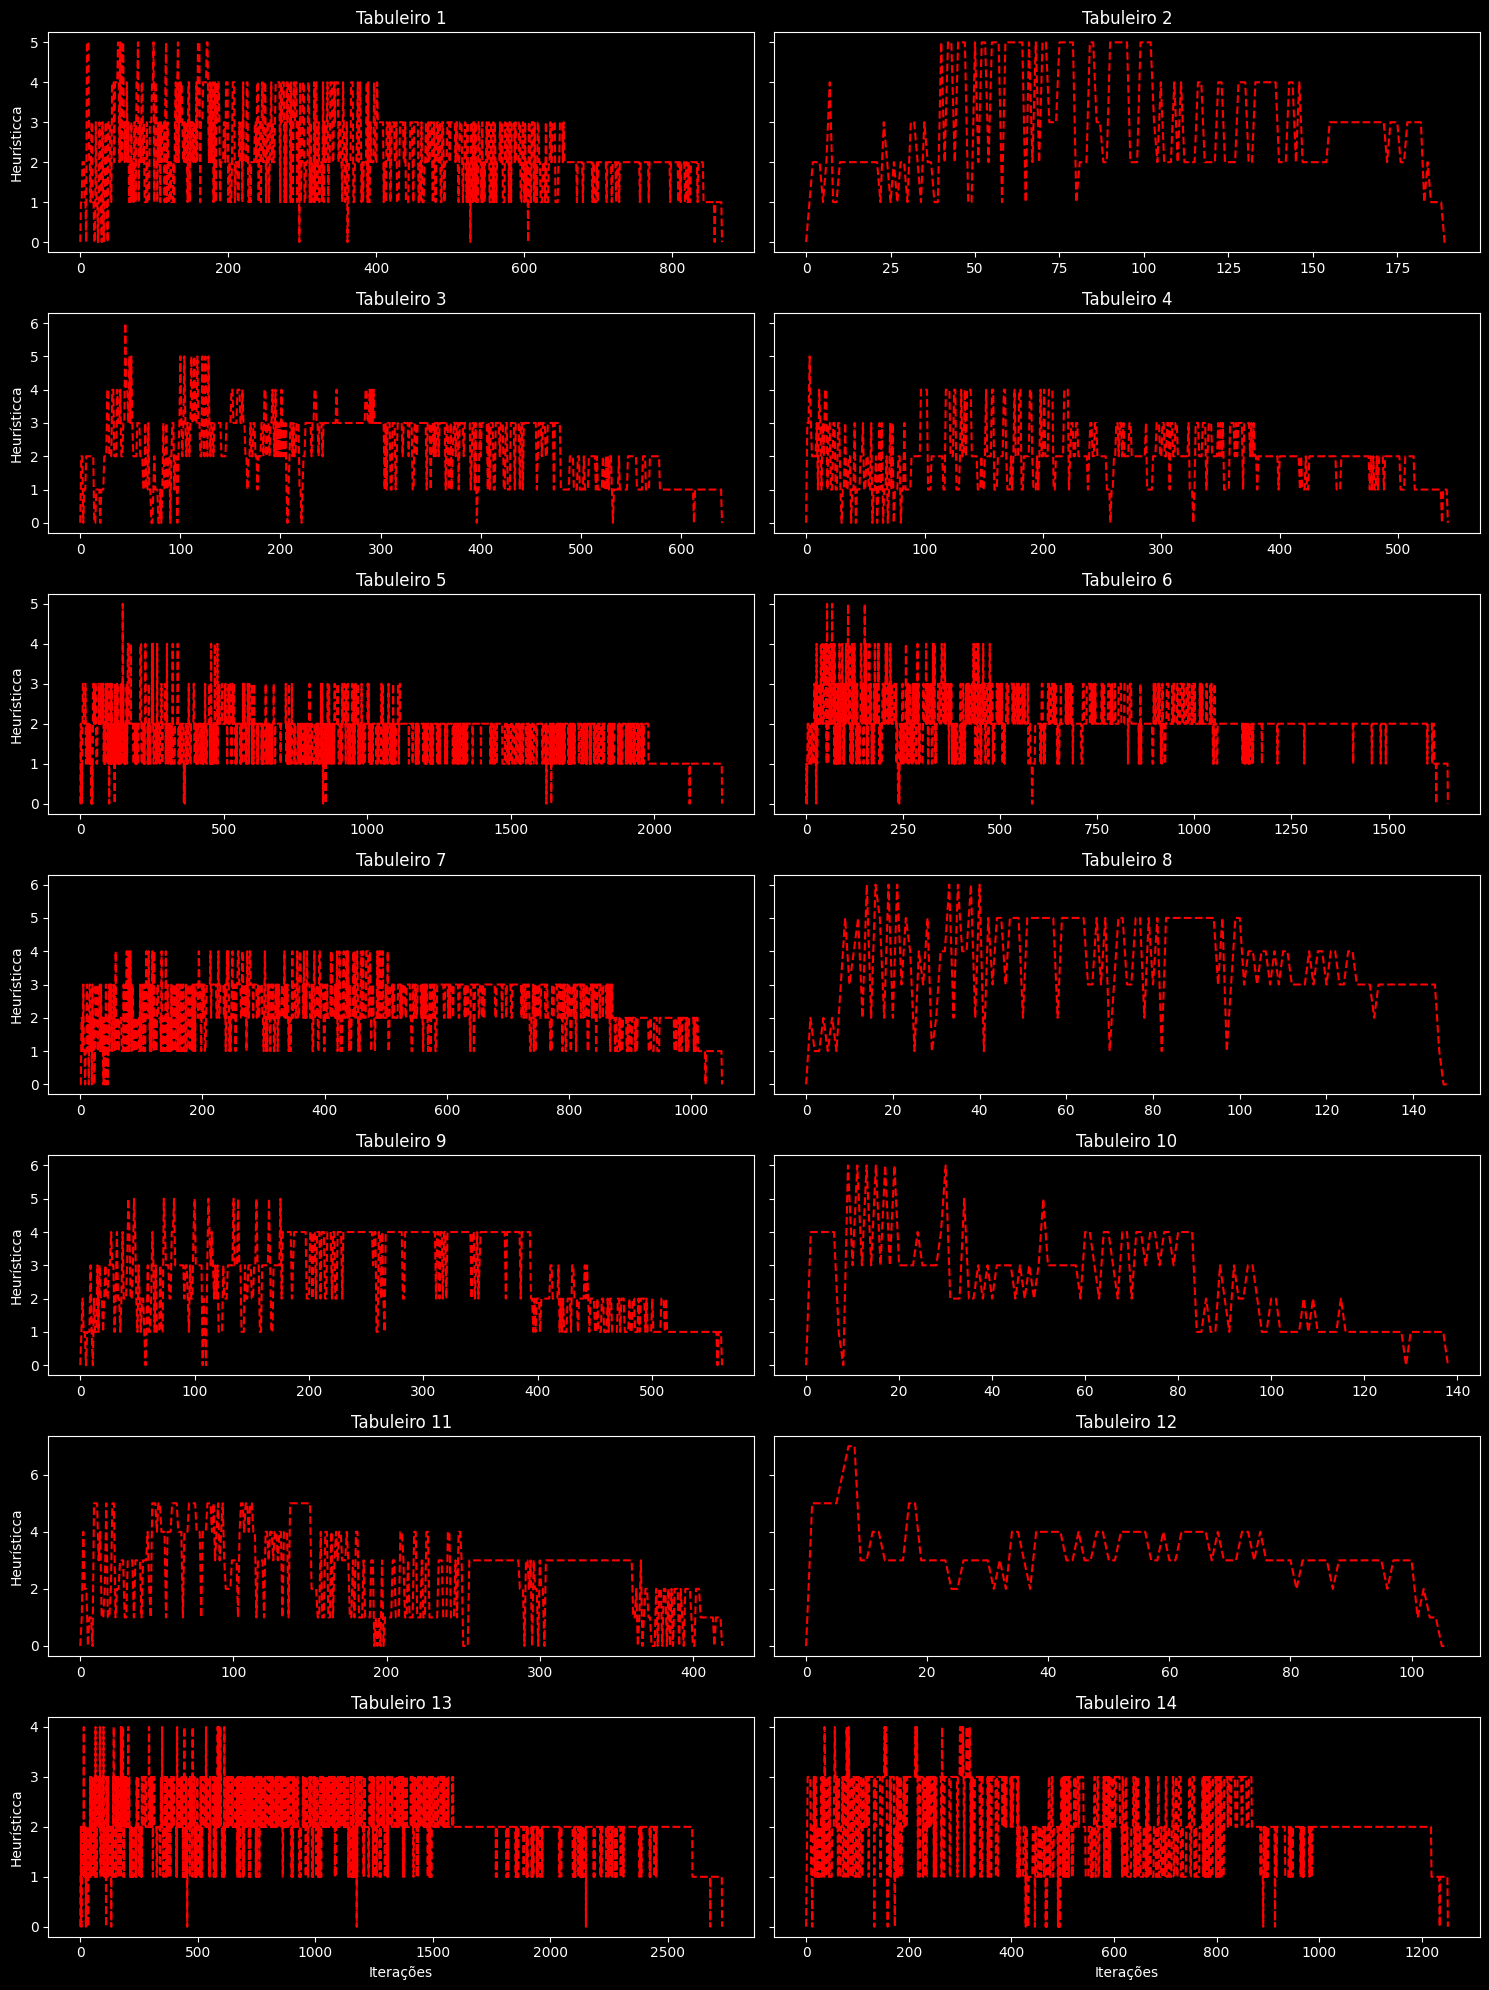

########################################################################
DFS



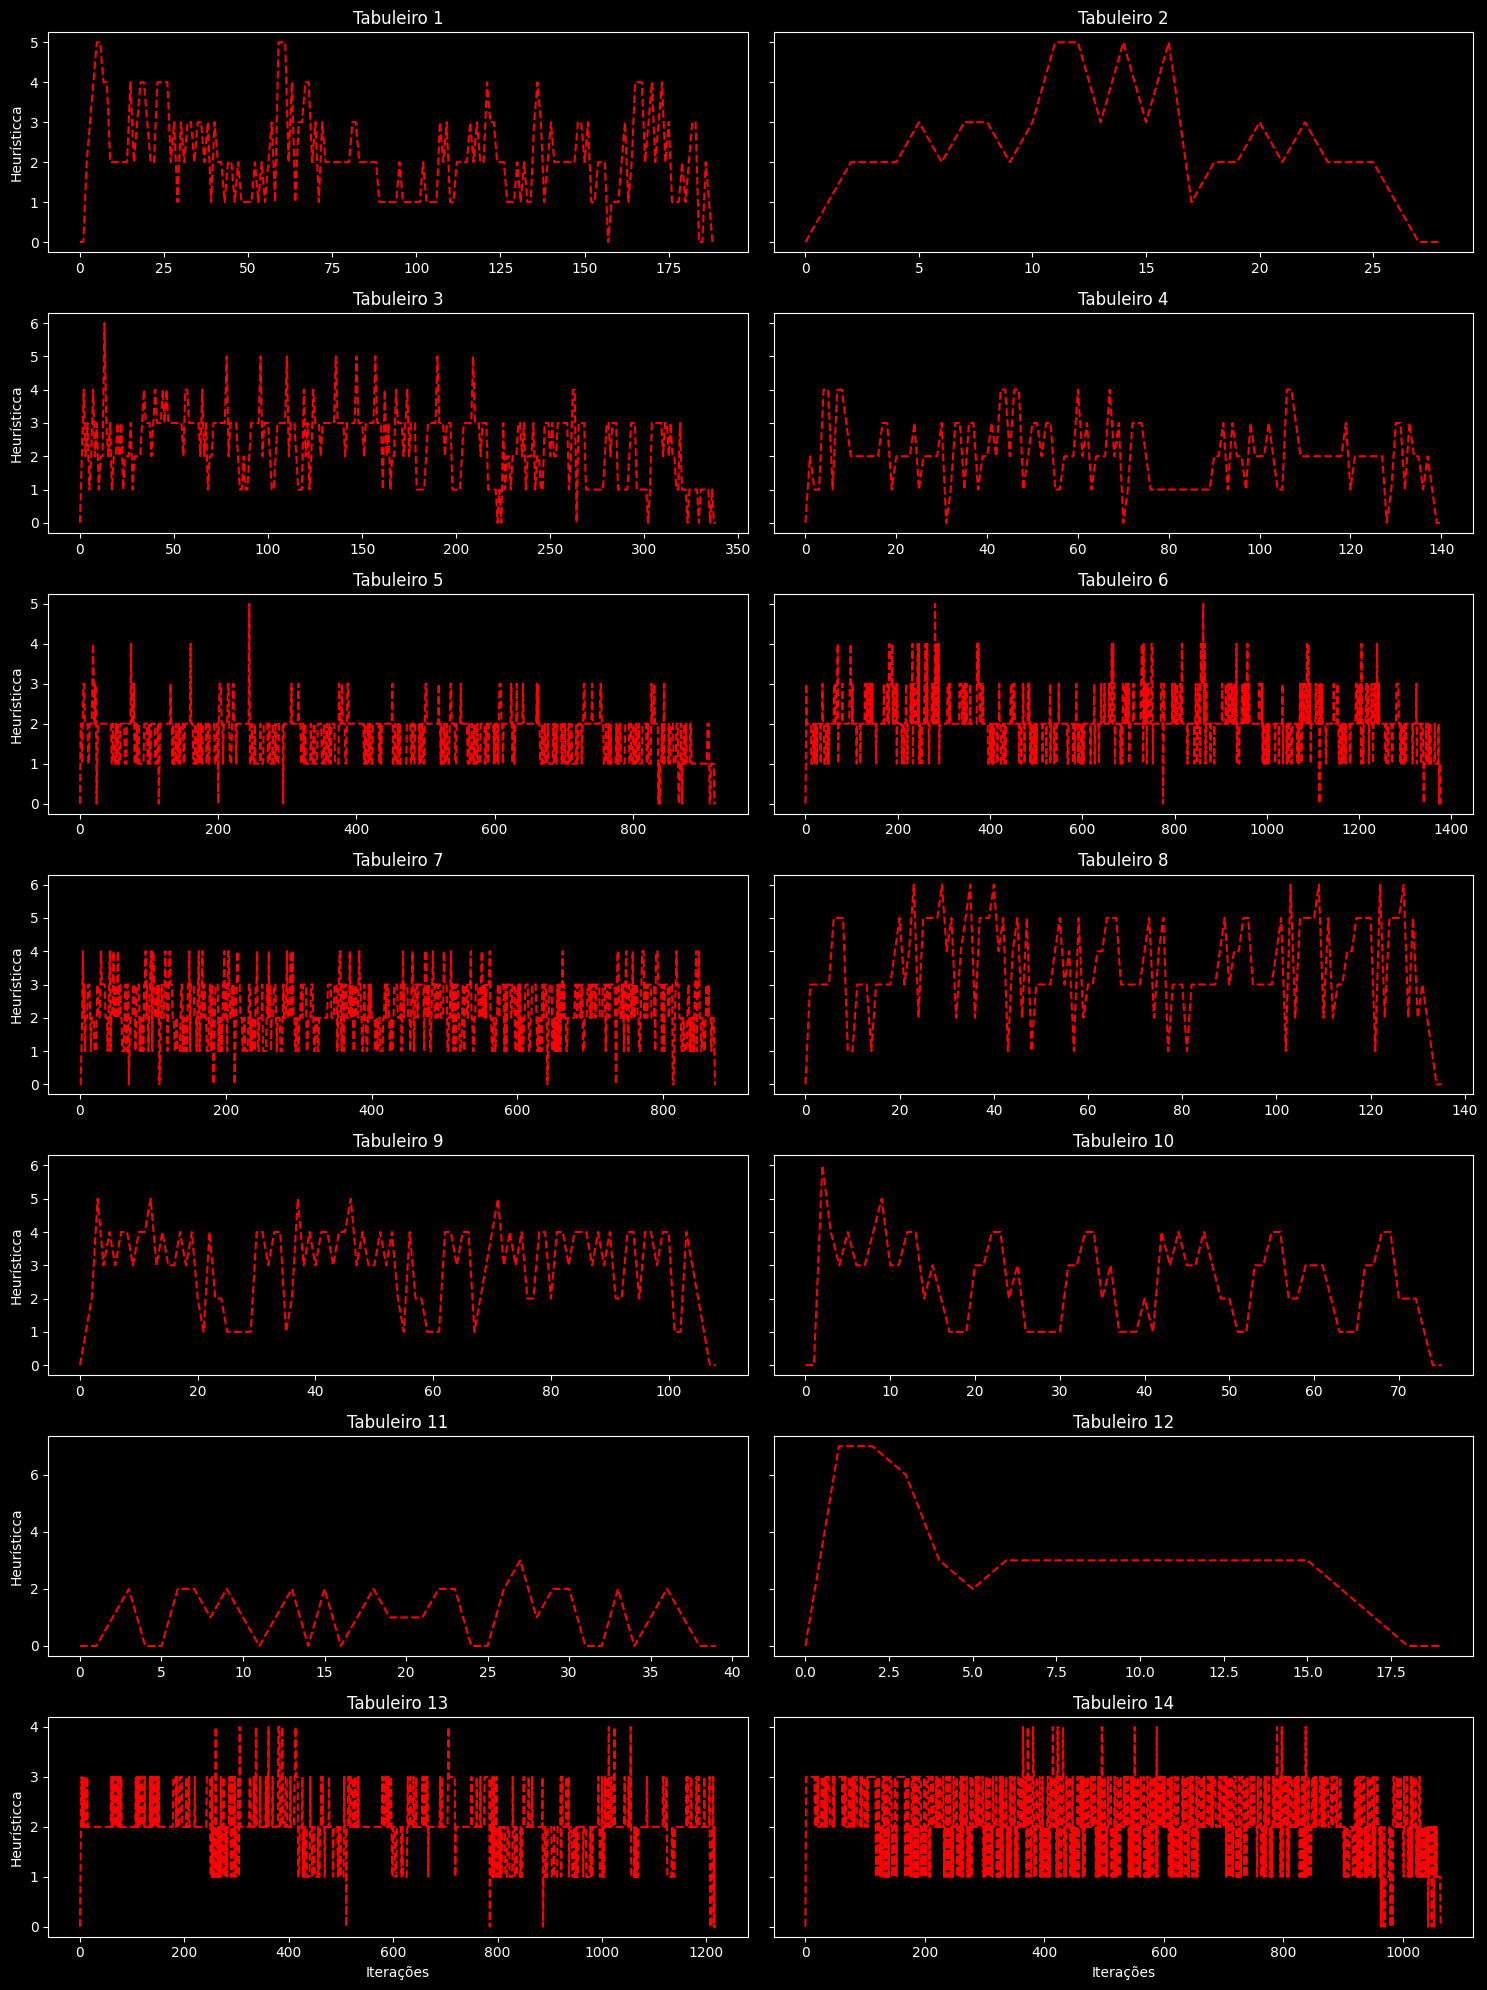

########################################################################
Busca Melhor Escolha



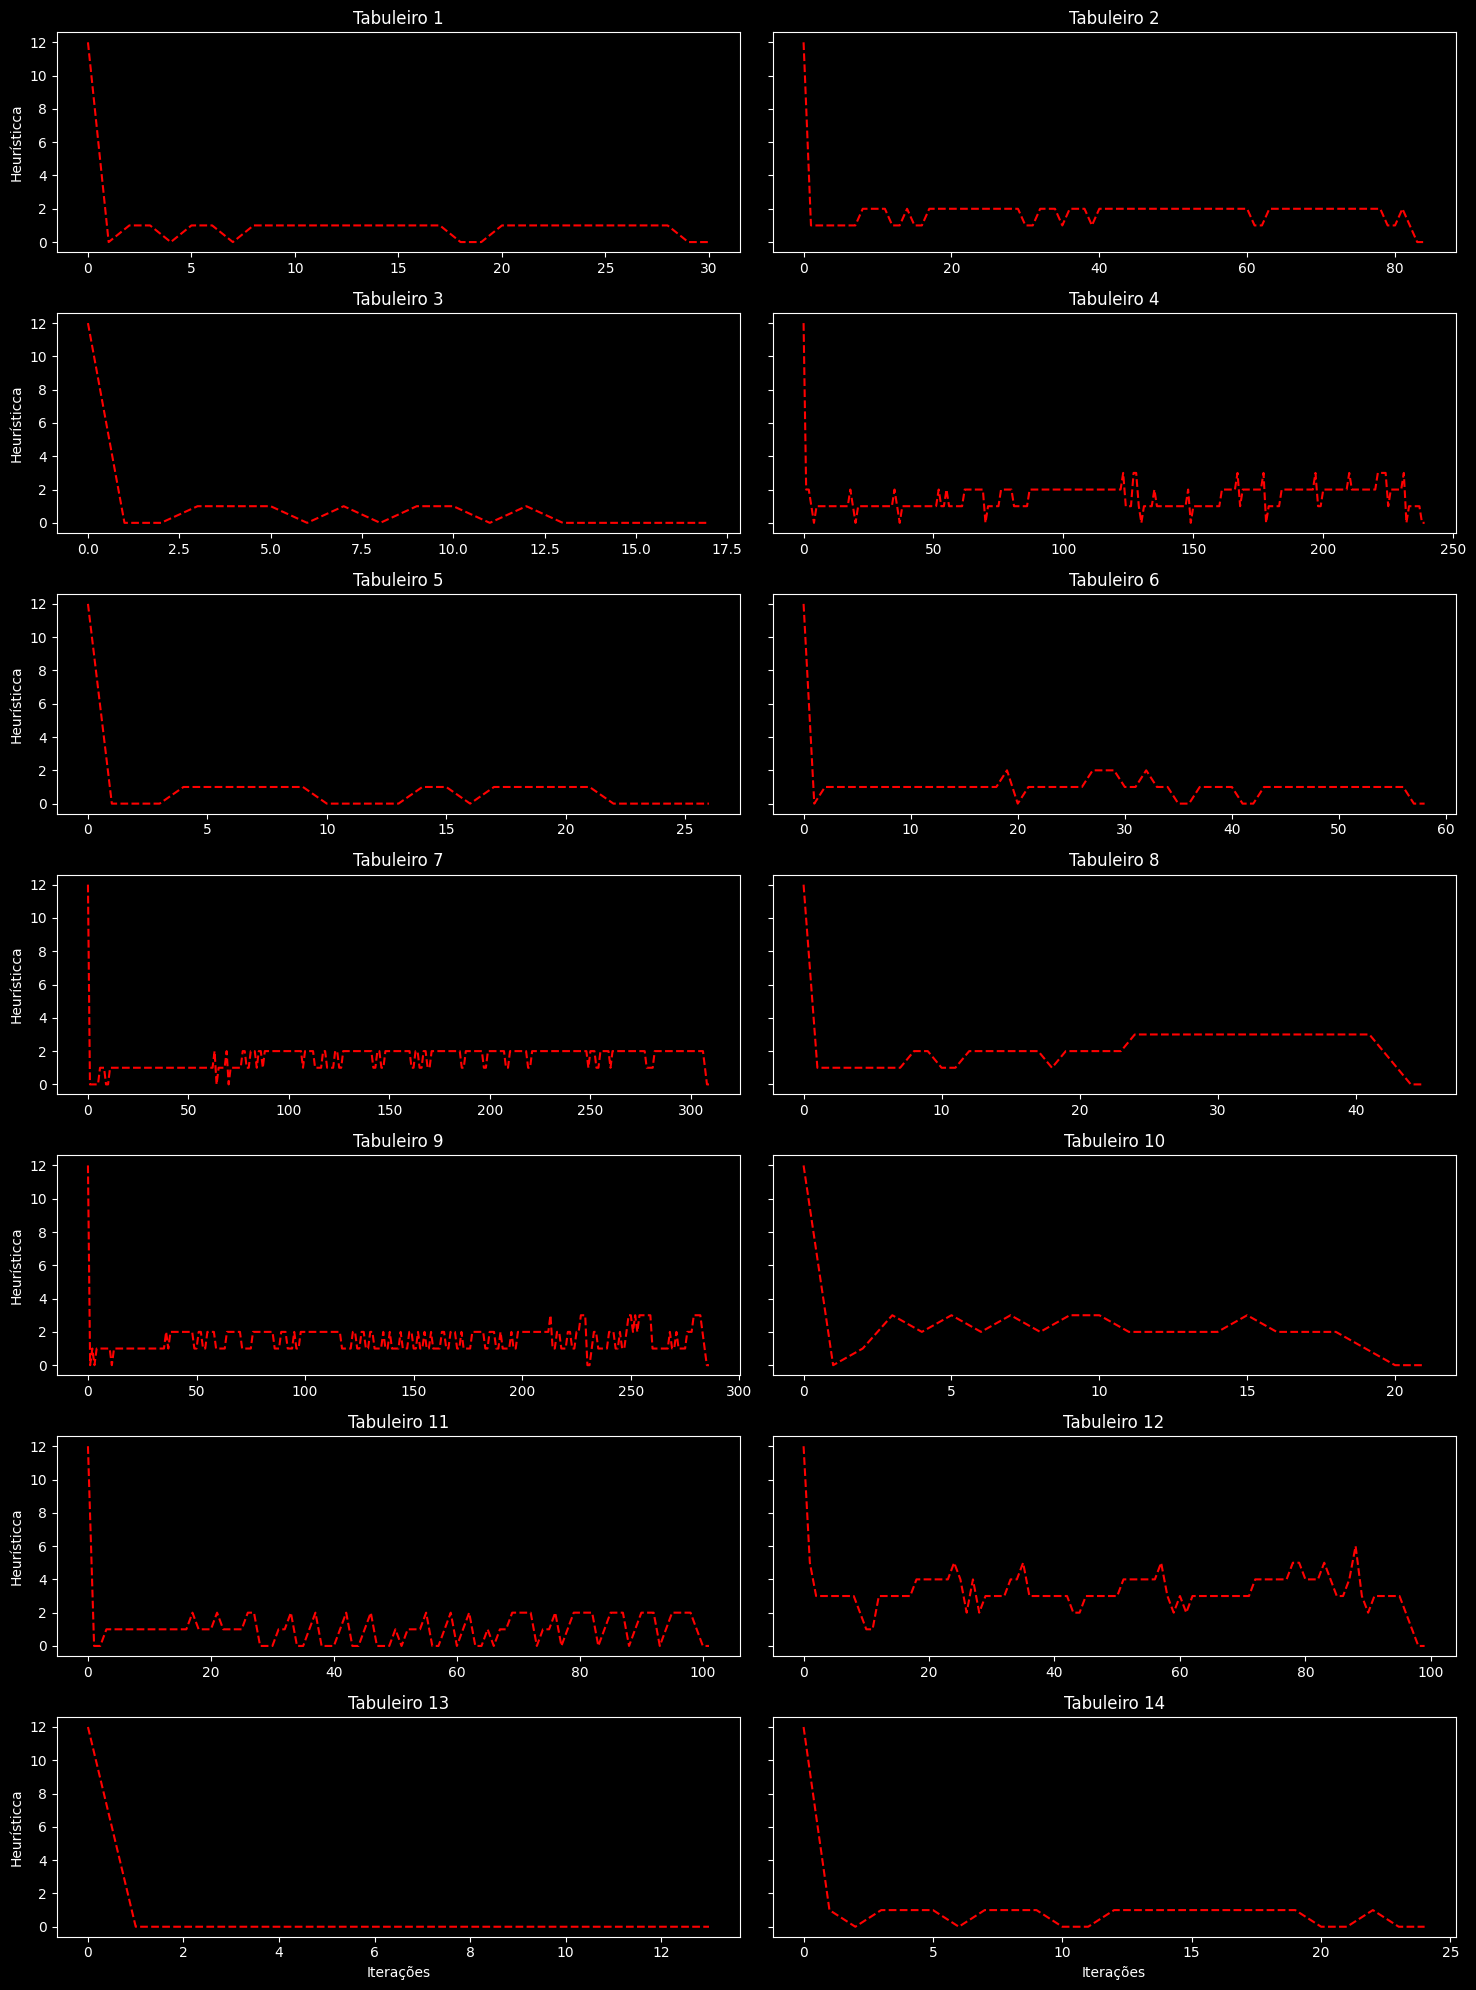

########################################################################
A*



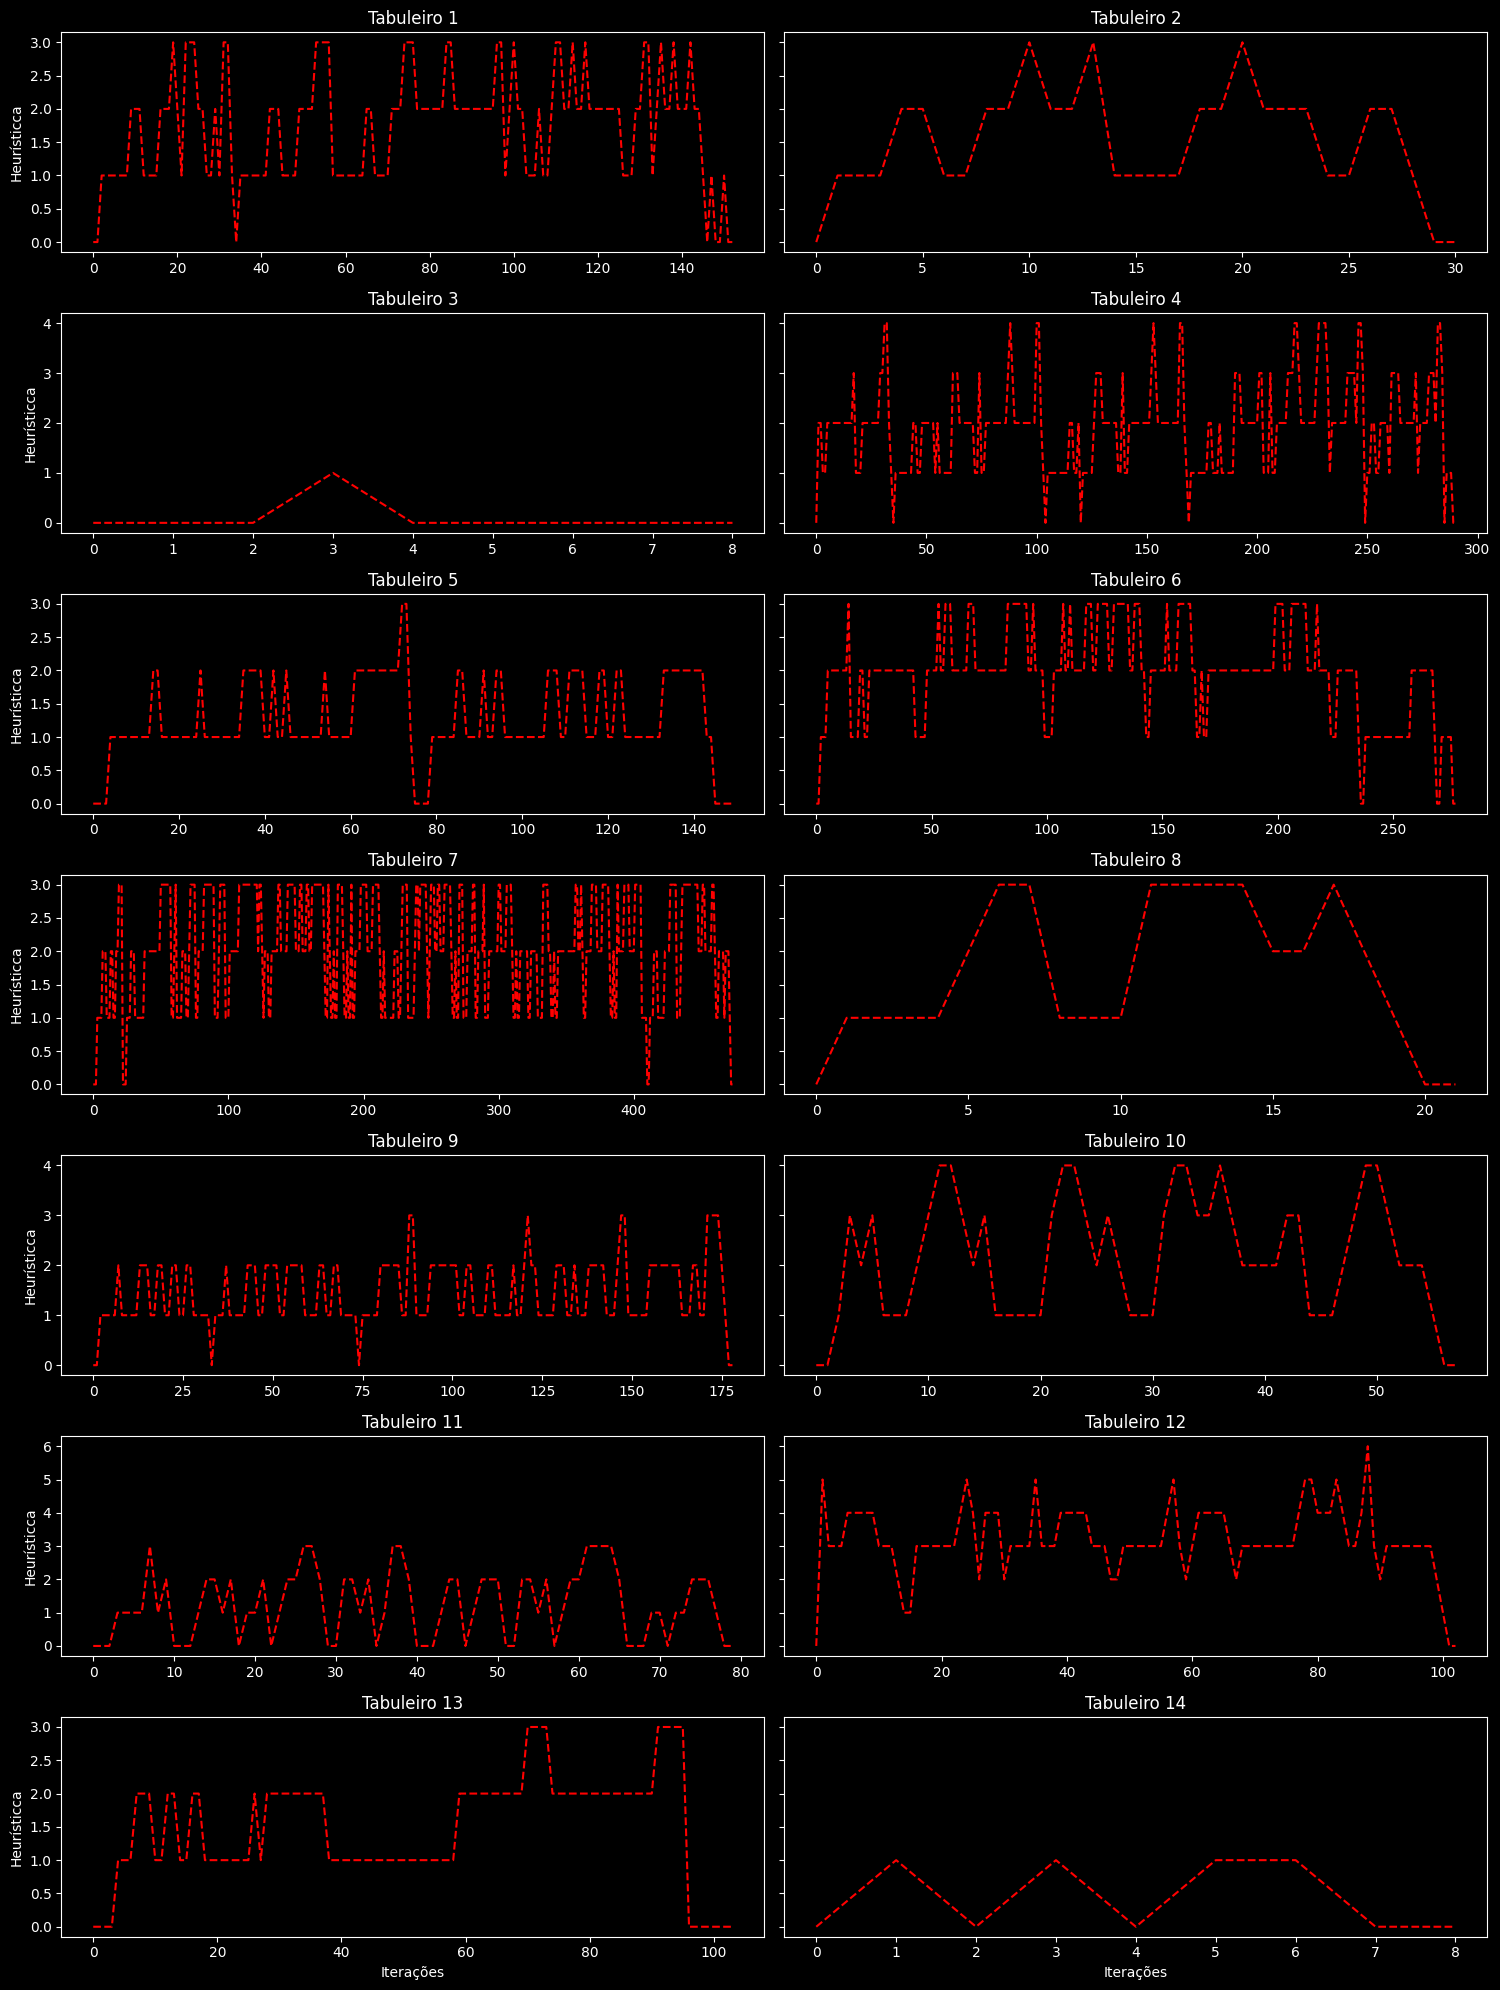

In [57]:
exibe_graficos_convergência(historico_algoritmos_deterministicos, True)

In [22]:
exibe_quantidade_iteracoes(historico_algoritmos_deterministicos, True)

########################################################################
BFS

╒═════════════╤═════════════╕
│  Tabuleiro  │  Iterações  │
╞═════════════╪═════════════╡
│     01      │     868     │
├─────────────┼─────────────┤
│     02      │     191     │
├─────────────┼─────────────┤
│     03      │     642     │
├─────────────┼─────────────┤
│     04      │     543     │
├─────────────┼─────────────┤
│     05      │    2237     │
├─────────────┼─────────────┤
│     06      │    1654     │
├─────────────┼─────────────┤
│     07      │    1051     │
├─────────────┼─────────────┤
│     08      │     149     │
├─────────────┼─────────────┤
│     09      │     562     │
├─────────────┼─────────────┤
│     010     │     139     │
├─────────────┼─────────────┤
│     011     │     420     │
├─────────────┼─────────────┤
│     012     │     107     │
├─────────────┼─────────────┤
│     013     │    2731     │
├─────────────┼─────────────┤
│     014     │    1252     │
╘═════════════╧═══════

In [23]:
calcula_metricas_estatisticas(historico_algoritmos_deterministicos, True)

########################################################################
BFS - Análise da quantidade de iterações para resolver o LinkedIn Queens

╒═════════════════╤═════════════════╕
│  Média simples  │  Desvio Padrão  │
╞═════════════════╪═════════════════╡
│     896.143     │     786.923     │
╘═════════════════╧═════════════════╛

########################################################################


########################################################################
DFS - Análise da quantidade de iterações para resolver o LinkedIn Queens

╒═════════════════╤═════════════════╕
│  Média simples  │  Desvio Padrão  │
╞═════════════════╪═════════════════╡
│     466.929     │     484.752     │
╘═════════════════╧═════════════════╛

########################################################################


########################################################################
Busca Melhor Escolha - Análise da quantidade de iterações para resolver o LinkedIn Queens

╒═════════

## **Comparação entre os algoritmos determinísticos**

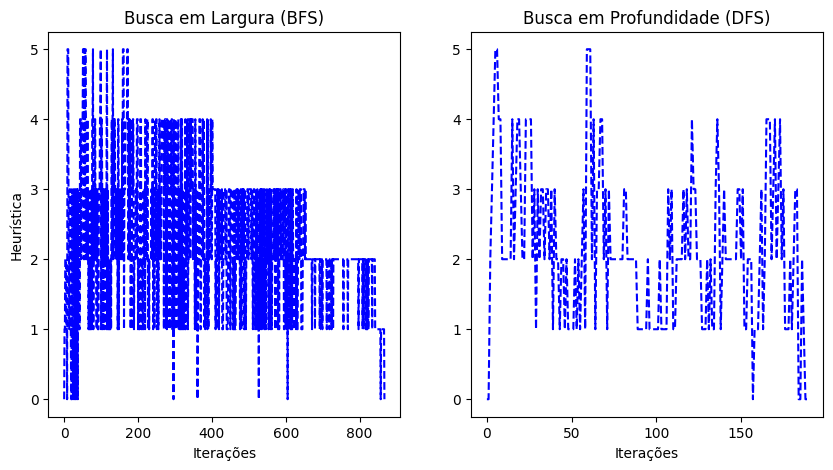

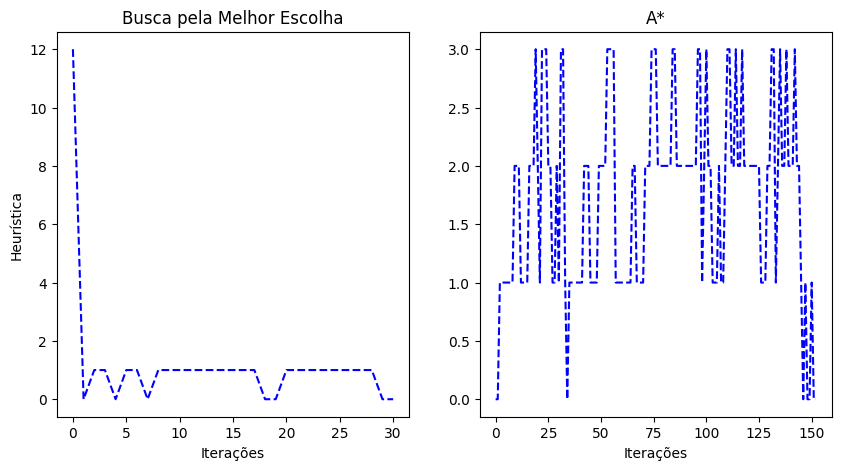

In [ ]:
# retorna plano de fundo para a versão light (default)
plt.style.use('default')

# cria subplot com dois gráficos
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

# armazena histórico do algoritmo no buffer
buffer = historico_algoritmos_deterministicos["BFS"][0]

# cria gráfico de convergência 
axs[0].plot(range(len(buffer)), buffer, color='blue', linestyle='--')
axs[0].set_title('Busca em Largura (BFS)')
axs[0].set_xlabel('Iterações')       
axs[0].set_ylabel('Heurística')

# repete processo para os demais algoritmos
buffer = historico_algoritmos_deterministicos["DFS"][0]

axs[1].plot(range(len(buffer)), buffer, color='blue', linestyle='--')
axs[1].set_title('Busca em Profundidade (DFS)')
axs[1].set_xlabel('Iterações')       
        
plt.show()

fig, axs = plt.subplots(1, 2, figsize=(10, 5))

buffer = historico_algoritmos_deterministicos["Busca Melhor Escolha"][0]

axs[0].plot(range(len(buffer)), buffer, color='blue', linestyle='--')
axs[0].set_title('Busca pela Melhor Escolha')
axs[0].set_xlabel('Iterações')       
axs[0].set_ylabel('Heurística')

buffer = historico_algoritmos_deterministicos["A*"][0]

axs[1].plot(range(len(buffer)), buffer, color='blue', linestyle='--')
axs[1].set_title('A*')
axs[1].set_xlabel('Iterações')       
        
plt.show()

## **Algoritmos Não Determinísticos**

########################################################################
SA



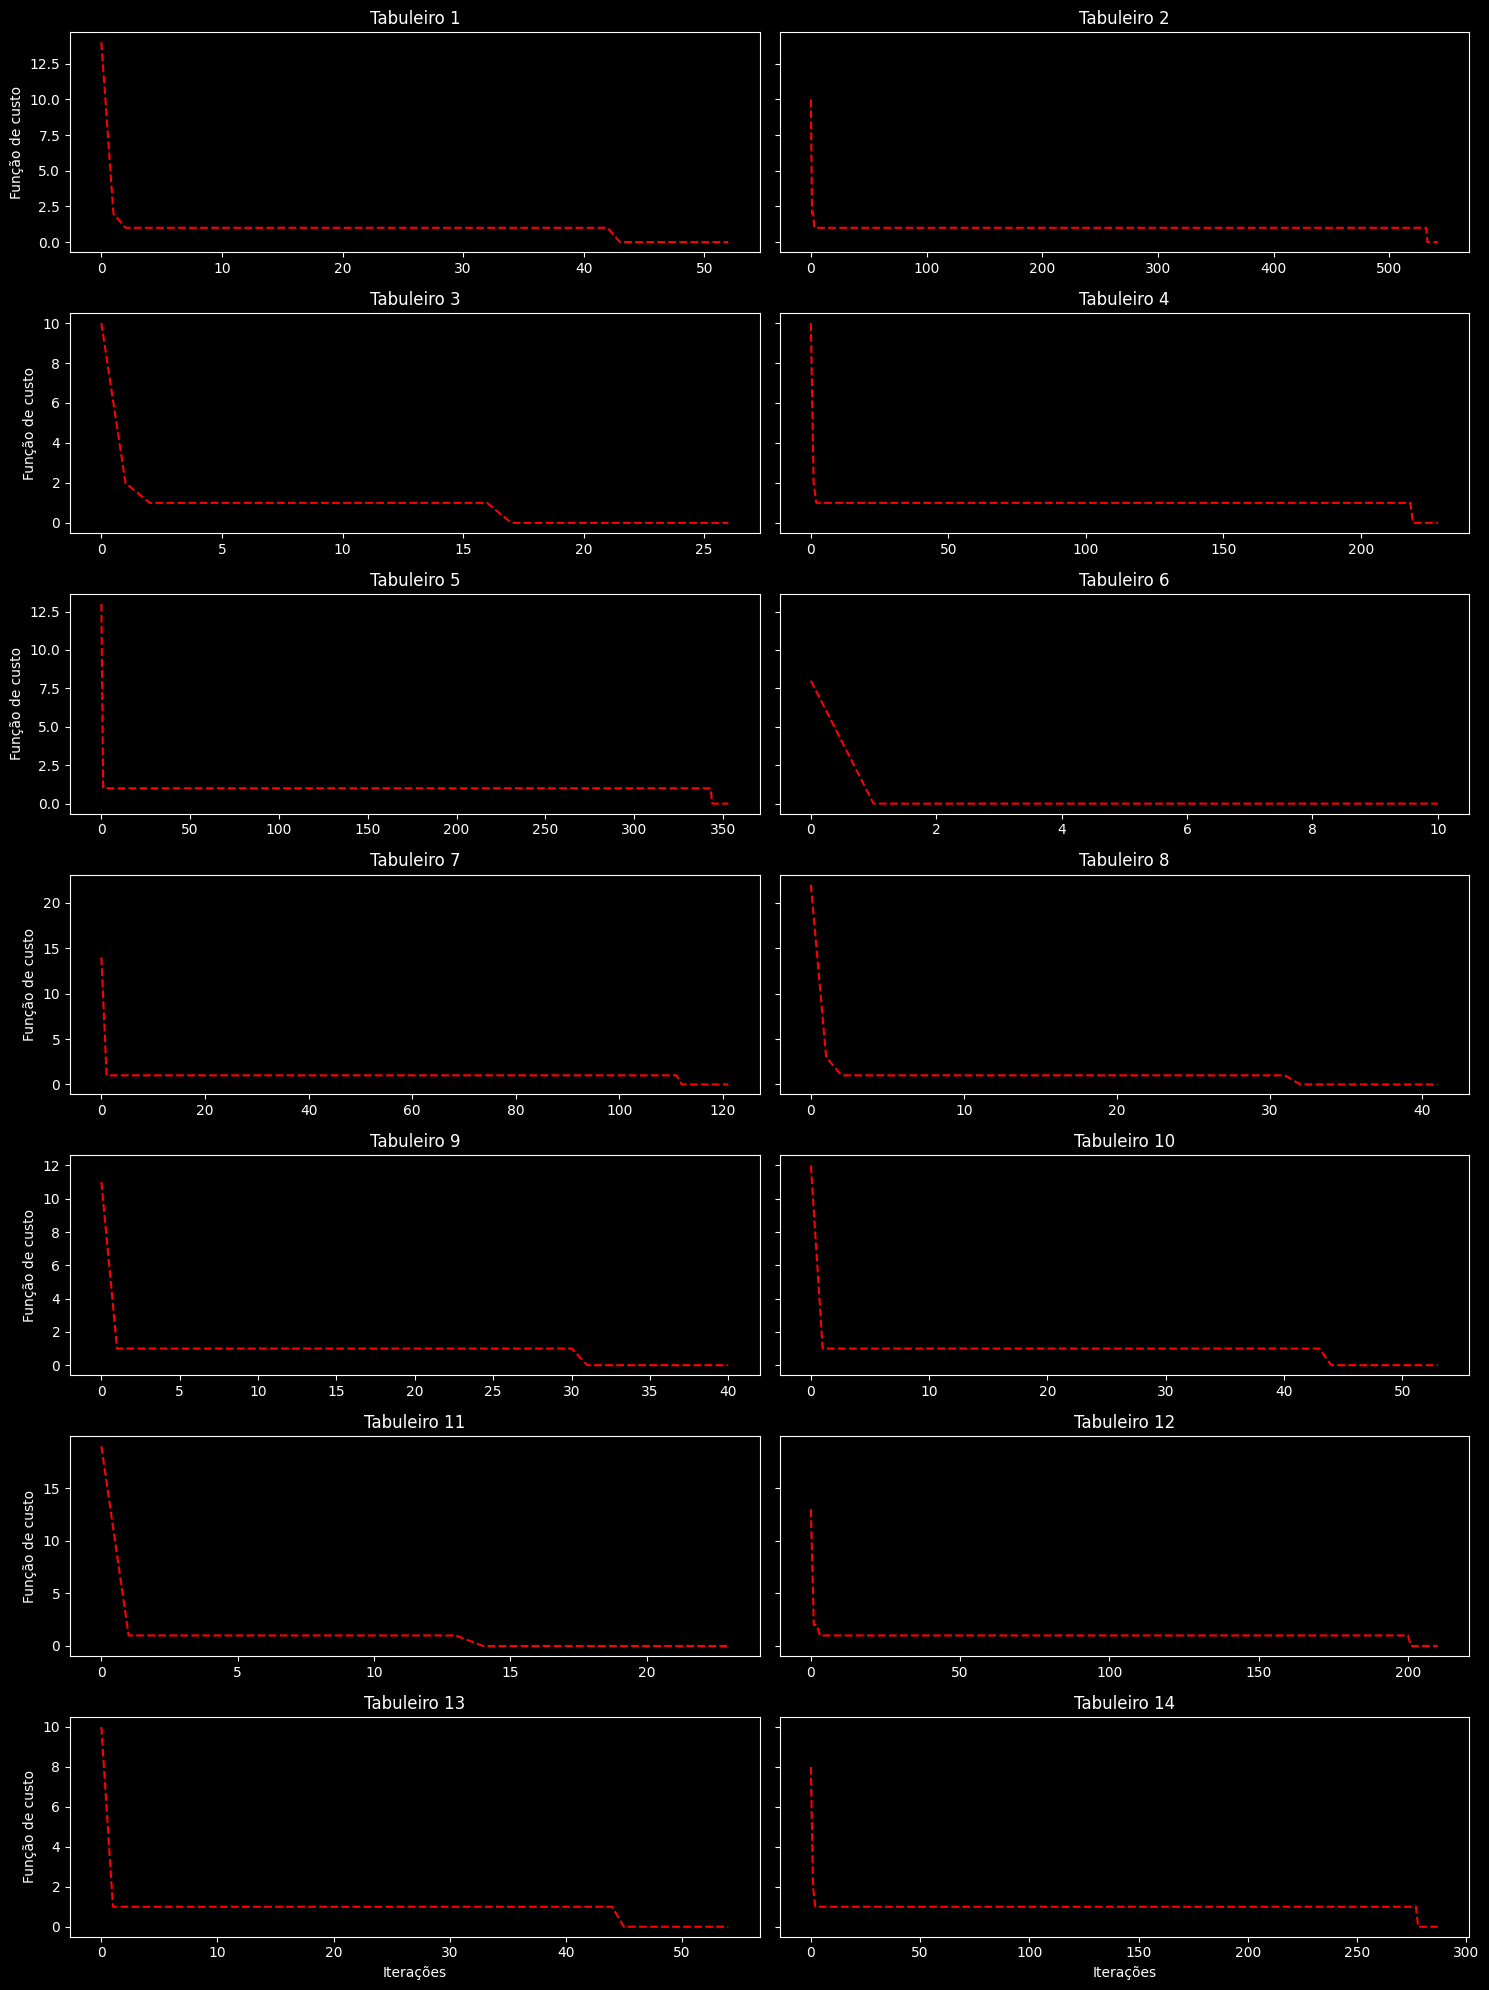

########################################################################
AG



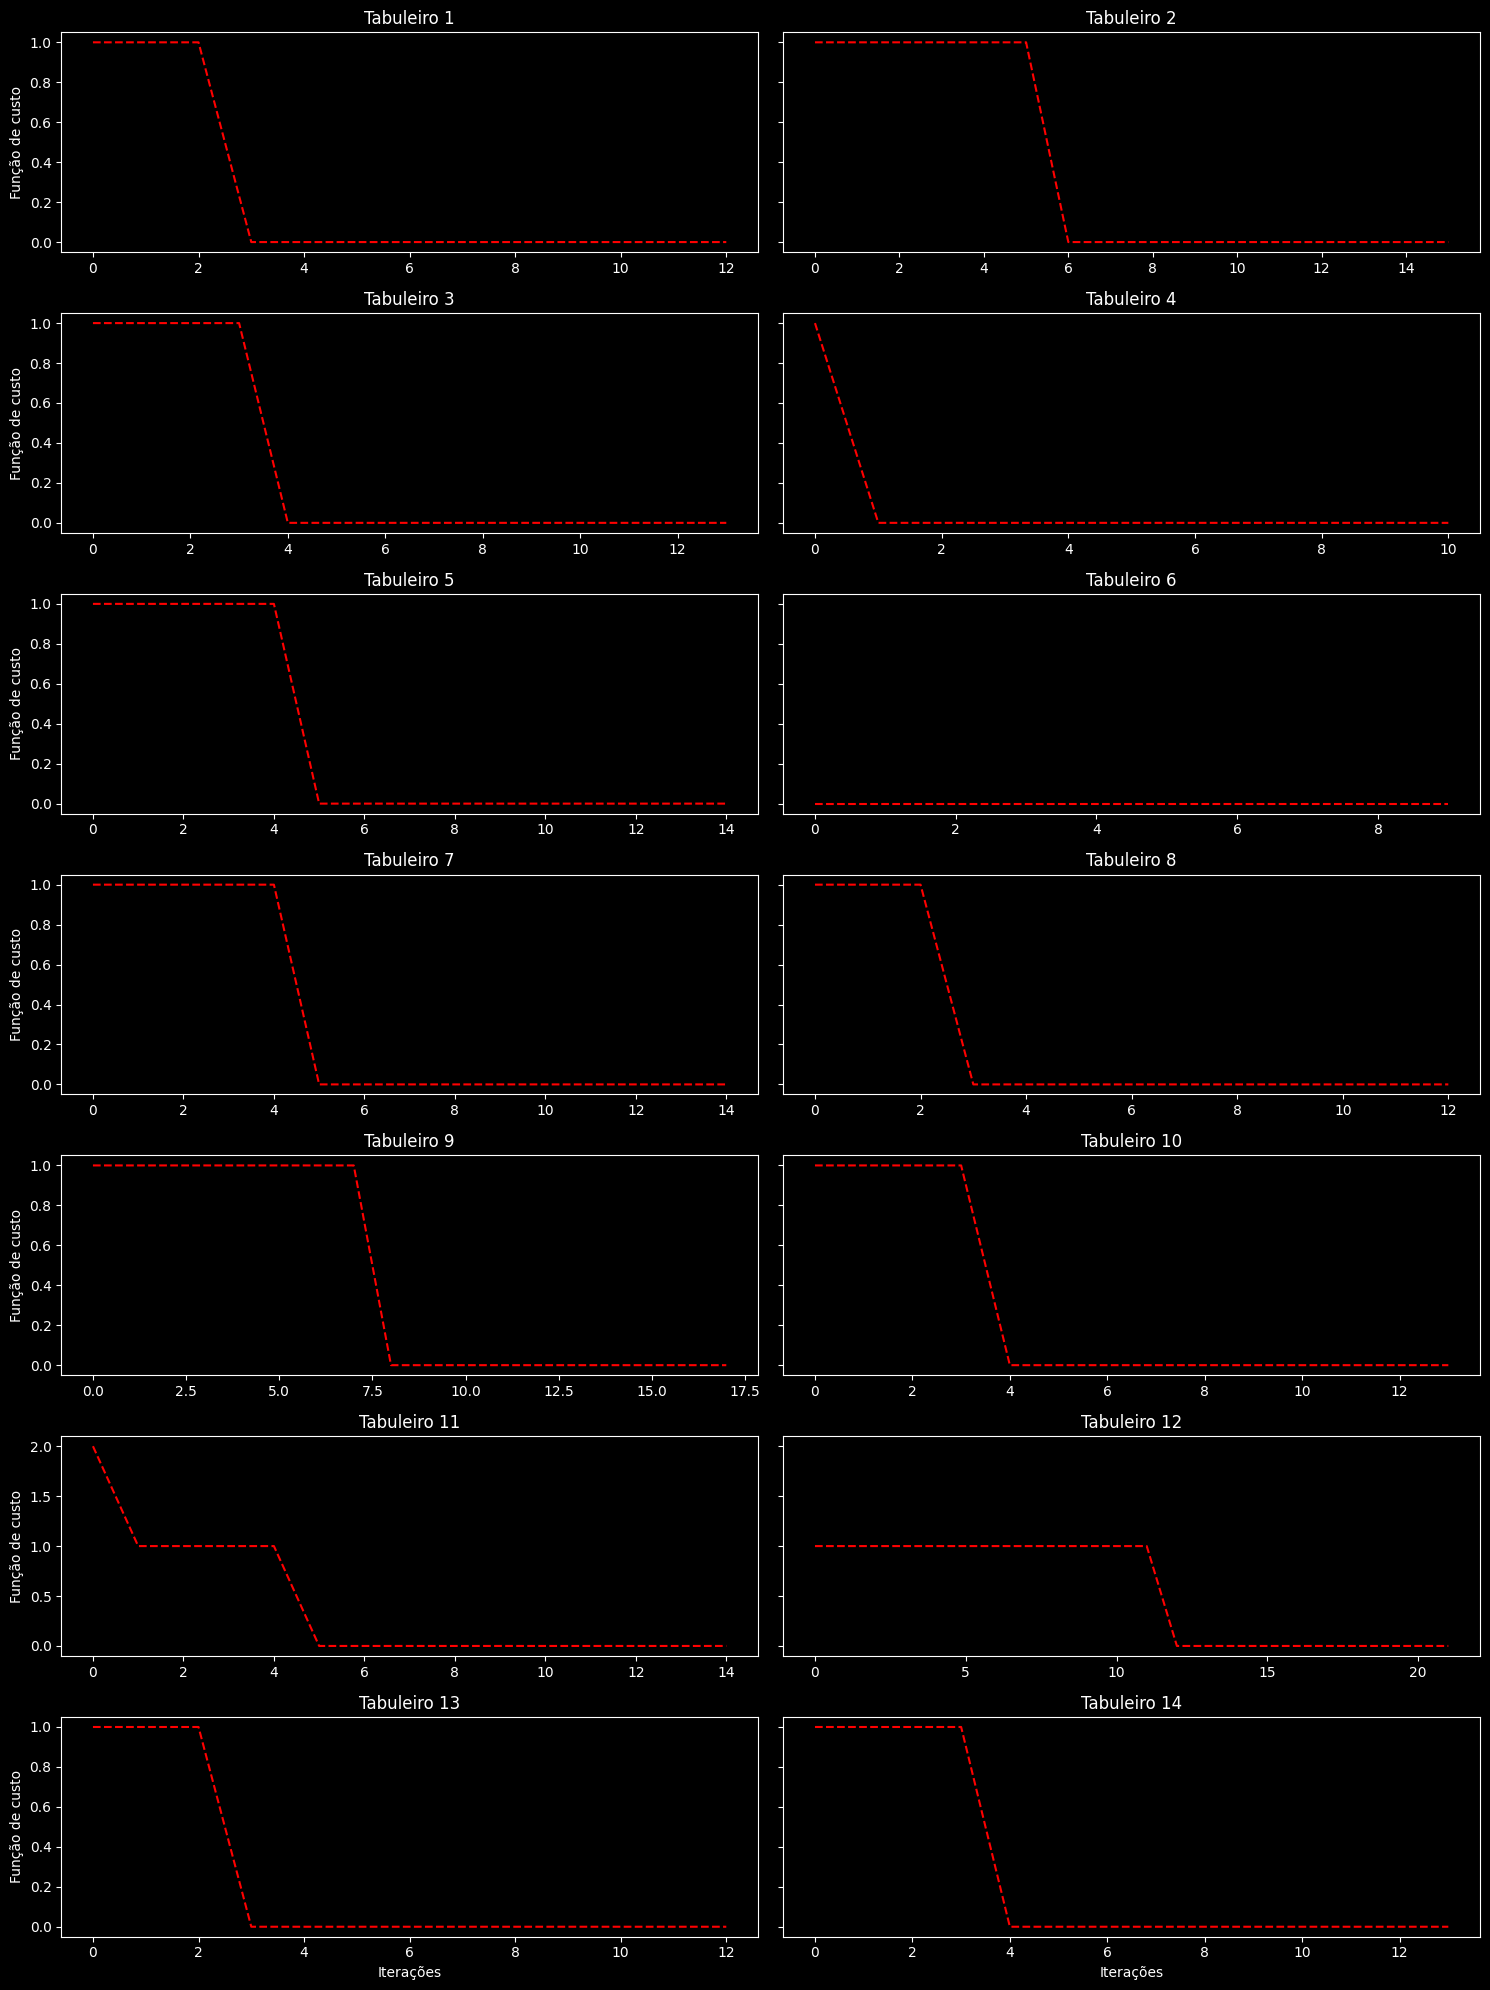

In [58]:
exibe_graficos_convergência(historico_algoritmos_nao_deterministicos, False)

In [25]:
exibe_quantidade_iteracoes(historico_algoritmos_nao_deterministicos, False)

########################################################################
SA

╒═════════════╤═════════════╕
│  Tabuleiro  │  Iterações  │
╞═════════════╪═════════════╡
│     01      │     44      │
├─────────────┼─────────────┤
│     02      │     534     │
├─────────────┼─────────────┤
│     03      │     18      │
├─────────────┼─────────────┤
│     04      │     220     │
├─────────────┼─────────────┤
│     05      │     345     │
├─────────────┼─────────────┤
│     06      │      2      │
├─────────────┼─────────────┤
│     07      │     113     │
├─────────────┼─────────────┤
│     08      │     33      │
├─────────────┼─────────────┤
│     09      │     32      │
├─────────────┼─────────────┤
│     010     │     45      │
├─────────────┼─────────────┤
│     011     │     15      │
├─────────────┼─────────────┤
│     012     │     202     │
├─────────────┼─────────────┤
│     013     │     46      │
├─────────────┼─────────────┤
│     014     │     279     │
╘═════════════╧════════

In [26]:
calcula_metricas_estatisticas(historico_algoritmos_nao_deterministicos, False)

########################################################################
SA - Análise da quantidade de iterações para resolver o LinkedIn Queens

╒═════════════════╤═════════════════╕
│  Média simples  │  Desvio Padrão  │
╞═════════════════╪═════════════════╡
│     137.714     │     152.883     │
╘═════════════════╧═════════════════╛

########################################################################


########################################################################
AG - Análise da quantidade de iterações para resolver o LinkedIn Queens

╒═════════════════╤═════════════════╕
│  Média simples  │  Desvio Padrão  │
╞═════════════════╪═════════════════╡
│       5.5       │     2.82211     │
╘═════════════════╧═════════════════╛

########################################################################




## **Comparação entre os algoritmos não-determinísticos**

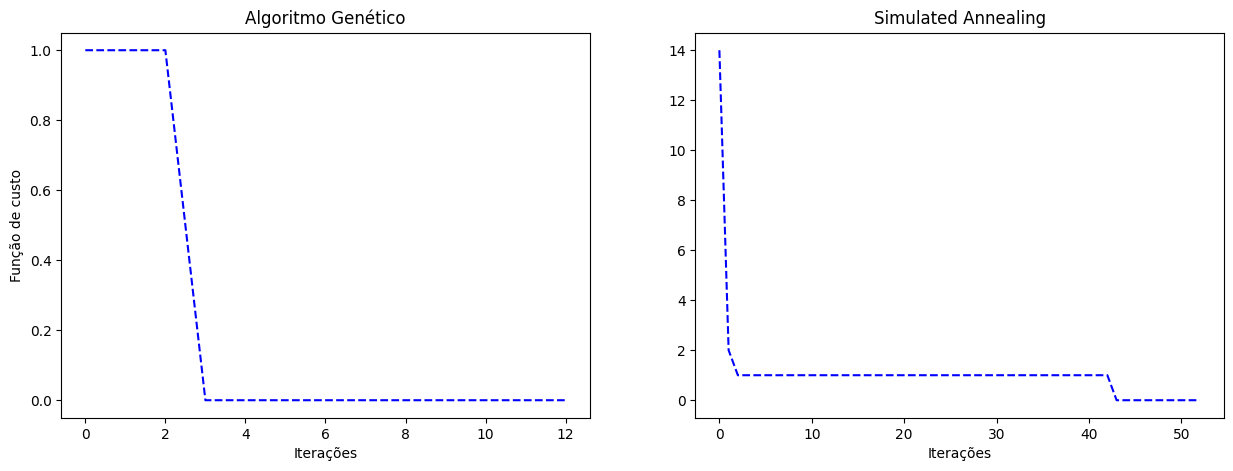

In [ ]:
# processo análogo ao realizado na comparação de algoritmos determinísticos 

plt.style.use('default')

fig, axs = plt.subplots(1, 2, figsize=(15, 5))

buffer = historico_algoritmos_nao_deterministicos["AG"][0][0:historico_algoritmos_nao_deterministicos["AG"][0].index(0) + 10]

axs[0].plot(range(len(buffer)), buffer, color='blue', linestyle='--')
axs[0].set_title('Algoritmo Genético')
axs[0].set_xlabel('Iterações')       
axs[0].set_ylabel('Função de custo')

buffer = historico_algoritmos_nao_deterministicos["SA"][0][0:historico_algoritmos_nao_deterministicos["SA"][0].index(0) + 10]

axs[1].plot(range(len(buffer)), buffer, color='blue', linestyle='--')
axs[1].set_title('Simulated Annealing')
axs[1].set_xlabel('Iterações')       
        
plt.show()